<a href="https://colab.research.google.com/github/anaacevedo1980/Data_Science_II/blob/main/entrega_final_data_sciencie_ii_acevedo_ana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Alumna: Acevedo Ana**
## **Curso Data Science II**
## **CoderHouse**

# **Modelado Predictivo de Costos en Logística: Enfoque de Machine Learning**

El presente proyecto tiene como objetivo analizar y modelar el comportamiento logístico de un servicio de encomienda a partir de un conjunto de datos que documenta el flujo completo de envíos de extremo a extremo. Este dataset incluye información detallada sobre remitente y destinatario, peso real y volumétrico, modalidad de entrega (Express, Surface, Air Cargo), cargos aplicados (tarifa base, recargos por servicios adicionales, peso facturable) y estado operativo del envío.

A través de técnicas de análisis exploratorio, detección de outliers y visualización multivariada, se busca comprender los patrones que rigen la estructura de costos y el desempeño operativo del sistema. Posteriormente, se implementarán modelos predictivos que permitan estimar el monto total facturado en función de variables logísticas clave, con el fin de optimizar la toma de decisiones en procesos de tarificación, planificación y eficiencia operativa.

Para guiar el análisis, se plantean las siguientes hipótesis:

1) **Influencia del peso facturable**

H₀: El peso facturable (Chargeable Wt) no tiene un efecto significativo sobre el monto total (Total Amount).

H₁: El peso facturable sí tiene un efecto significativo sobre el monto total.

2) **Diferencias por modo de envío**

H₀: El modo de envío (Mode) no influye en el monto total facturado.

H₁: El modo de envío sí influye en el monto total facturado.

3) **Cargos adicionales**

H₀: Los cargos por servicios adicionales (VAS Charges) no afectan significativamente el monto total.

H₁: Los cargos por servicios adicionales sí afectan significativamente el monto total.

4) **Modelo multivariable**

H₀: Ninguna de las variables independientes (peso, piezas, modo, recargos) tiene efecto significativo sobre el monto total.

H₁: Al menos una de las variables independientes tiene efecto significativo sobre el monto total.

Este enfoque permitirá no solo validar estadísticamente el impacto de cada variable, sino también construir modelos robustos de predicción que puedan ser aplicados en entornos reales de logística y distribución.

## Descripción de columnas

   **Origin:** La ciudad desde la que se reservó originalmente o despachó la parcela.

   **Destination:** La ciudad donde se pretende entregar la parcela.

   **Pouch No:** Un identificador interno único (a menudo UUID) utilizado para agrupar envíos en logística.

   **Date:** La fecha en que se reservaba el envío, representado en formato número serie de Excel.

   **Sender's Name**: Nombre completo de la persona o empresa que envía el paquete.

   **Sender Phone:** Número de contacto móvil o fijo del remitente.

  **Sender Address:** Dirección completa del remitente para la recogida y los registros.

  **Sender City:** La ciudad del remitente puede duplicar el campo "Origen".

  **Sender State:** El estado indio en el que se encuentra el remitente.

  **Sender Pincode:** El código postal de 6 dígitos (ZIP) de la ubicación del remitente.

  **Sender GSTIN:** GST Número de identificación del remitente (si procede en los envíos comerciales).

  **Total Pieces:** Número de paquetes físicos individuales incluidos en el envío.

  **Wt Actual:** El peso físico real (en kilogramos) de los paquetes.

  **Volumetric Wt:** El peso calculado sobre la base de las dimensiones de volumen, utilizado para los fines de facturación.

  **Chargeable Wt:** El peso utilizado para la facturación -normalmente el mayor de peso real o volumétrico.

  **Paperwork:** Indica si se presentó papeleo junto con el paquete (Sí/No).

  **Sender Signature:** Denota si el remitente firmó la documentación de despacho (Sí/No).

  **Sender Date:** La fecha en que el remitente completó los documentos de entrega o firmados, en formato serie Excel.

  **Recipient Name:** El nombre completo de la persona u organización pretendía recibir el paquete.

  **Recipient Phone**: El número de contacto del destinatario previsto.

  **Recipient Address:** La dirección de entrega completa donde debe enviarse el paquete.

  **Recipient City:** La ciudad del destinatario puede duplicar el campo "Destino".

  **Receiver State:** El estado indio donde reside el receptor.

  **Receiver Pincode:** El código postal o ZIP de 6 dígitos de la dirección de entrega.

  **Description:** Una breve descripción textual del contenido del paquete (por ejemplo, documentos, elementos).

  **Value Added Services:** Servicios opcionales añadidos al envío, como manipulación frágil, entrega exprés, seguros, etc.

  **Consignment No:** El número de seguimiento oficial de DTDC asignado al envío.

  **Expiry Date:** la última fecha válida para la entrega, después de la cual el envío puede expirar o ser devuelto. Almacenado como número de serie de Excel.

  **Booking Code**: El código único que identifica la sucursal de DTDC o contador de reservas.

  **Recipient GSTIN:** Número de identificación GST del destinatario (si procede).

  **Receiver Name:** Un campo alternativo o duplicado para el nombre del destinatario.

  **Relationship:** Describe la relación del receptor con el destinatario original (por ejemplo, uno mismo, Personal, Familia).

  **Company Stamp:** Indica si se utilizó un sello de la empresa durante el recibo (Sí/No).

  **Receiver Signaturer:** Indica si el destinatario firmó la confirmación de entrega (Sí/No).

  **Receive Date:** La fecha en que se recibió el paquete, en formato serie de Excel.

  **Tariff:** La carga de entrega de la base en rupias indias.

  **VAS Charges:** Cargos adicionales por cualquier servicio de valor agregado aplicado al envío.

  **Total Amount:** El importe total facturado para el envío, incluyendo tarifas y complementos.

  **Mode:** El modo de envío elegido . Superficie, aire o Express.

  **Risk Surcharge:** Denota quién asume la responsabilidad de riesgo - el propietario (enferr) o Carrier (DTDC).

  **Mode of Payment:** El método de pago utilizado en la reserva, como Efectivo, Tarjeta, UPI, Wallet, etc.
    
  **Nature of Consignment:** Indica el tipo de paquete de paquetería "Dox" para documentos o "No-Dox" para mercancías/mercancías.

Fuente: https://www.kaggle.com/datasets/ravindrasinghrana/dtdc-courier-dataset/data

In [ ]:
# INSTALACION LIBRERÍAS

!pip install ipyleaflet #PARA MAPA INTERACTIVO

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS

# --- LIBRERÍAS DE DATOS ---
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# --- VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- ANÁLISIS ESTADÍSTICO ---
from scipy import stats
from scipy.stats import normaltest, shapiro, kstest, chi2_contingency
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- API
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.distance import geodesic
from tqdm import tqdm

#----MAPA INTERACTIVO
from ipyleaflet import Map, CircleMarker, Polyline, LayerGroup
from ipywidgets import Layout, HTML # Import HTML widget

# LIBRERÍAS PARA MACHINE LEARNING

# PREPROCESAMIENTO
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# MODELOS DE REGRESION
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
import xgboost as xgb

# OPTIMIZACION
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# METRICAS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error



In [ ]:
# Configuración de visualización
#  Azul corporativo más fuerte (gama consistente y muy visible)
palette_azules_fuertes = [
    "#1B4F72",  # Azul profundo
    "#21618C",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#5DADE2",
    "#85C1E9",
    "#AED6F1"   # Azul claro
]
sns.set_palette(palette_azules_fuertes)

#  Ajustes globales de estilo
plt.style.use("seaborn-v0_8-darkgrid")
# Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

plt.rcParams["lines.linewidth"] = 2.5  # líneas más definidas
plt.rcParams["figure.figsize"] = (12, 6)        # tamaño por defecto
plt.rcParams["axes.titlesize"] = 14            # tamaño título
plt.rcParams["axes.labelsize"] = 12            # etiquetas ejes
plt.rcParams["axes.titleweight"] = "bold"      # negrita título
plt.rcParams["axes.labelweight"] = "bold"      # negrita etiquetas
plt.rcParams["lines.linewidth"] = 2            # grosor de líneas

In [ ]:
import requests

url = "https://raw.githubusercontent.com/anaacevedo1980/ProyectoDataScienceI/refs/heads/main/Dataset_Generator_for_DTDC.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

Origin;Destination;Pouch No;Date;Sender's Name;Sender Phone;Sender Address;Sender City;Sender State;Sender Pincode;Sender GSTIN;Total Pieces;Actual Wt;Volumetric Wt;Chargeable Wt;Paperwork;Sender Signature;Sender Date;Recipient Name;Recipient Phone;Recipient Address;Recipient City;Receiver State;Rec


In [ ]:
df = pd.read_csv(url, sep=';') # lee el archivo,

In [ ]:
# GUARDAR COPIA ORIGINAL
df_original = df.copy()
print(f" Dataset original guardado: {df_original.shape}")

 Dataset original guardado: (49639, 42)


In [ ]:
df.head()# Muestra las primeras 5 filas

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,Sender GSTIN,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Paperwork,Sender Signature,Sender Date,Recipient Name,Recipient Phone,Recipient Address,Recipient City,Receiver State,Receiver Pincode,Description,Value Added Services,Consignment No,Expiry Date,Booking Code,Recipient GSTIN,Receiver Name,Relationship,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,25/6/2025,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,NaN,5,1.45,1.90,1.90,No,NaN,25/6/2025,Benjamin Kalla,1404091893,"H.No. 84, Palan Chowk, Above Shop, Jamshedpur,...",Jamshedpur,Jharkhand,950721,Quam beatae aperiam odio.,COD,DTDC25102909,25/7/2025,BR609,NaN,Benjamin Kalla,Family,NaN,NaN,30/6/2025,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,27/6/2025,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,UU73146GFVQTZ4,5,5.94,6.12,6.12,No,Yes,27/6/2025,Qushi Goyal,5538585979,"H.No. 376, Pandit, Near Park, Vizag, Andhra Pr...",Vizag,Andhra Pradesh,150138,Quas ipsam.,COD,DTDC49645557,27/7/2025,BR683,NaN,Qushi Goyal,Self,NaN,NaN,28/6/2025,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,27/6/2025,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,NaN,3,7.46,9.71,9.71,Yes,Yes,27/6/2025,Siddharth Gera,2173257324,"H.No. 40 Jaggi, Opposite Mall, Bhubaneswar, Od...",Bhubaneswar,Odisha,930670,Assumenda totam quaerat quod magnam.,Express,DTDC06690709,27/7/2025,BR984,NaN,Siddharth Gera,Friend,NaN,NaN,28/6/2025,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,11/6/2025,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,NaN,4,11.81,14.44,14.44,Yes,NaN,11/6/2025,Manbir Chakraborty,786556887,"524, Dhar, Near Park, Mumbai, Maharashtra - 47...",Mumbai,Maharashtra,479840,Rerum voluptatibus.,COD,DTDC50559265,11/7/2025,BR413,NaN,Manbir Chakraborty,Friend,NaN,NaN,15/6/2025,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,1/7/2025,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,NaN,3,5.97,6.72,6.72,No,Yes,1/7/2025,Sachi Bora,6906703769,"H.No. 824, Sanghvi Road, Opposite Mall, Vijaya...",Vijayawada,Andhra Pradesh,670910,Alias quos tempora.,COD,DTDC98609208,31/7/2025,BR742,NaN,Sachi Bora,Friend,NaN,NaN,5/7/2025,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [ ]:
df.describe()  # Estadísticas básicas de columnas numéricas

,Sender Phone,Sender Pincode,Total Pieces,Actual Wt,Volumetric Wt,Chargeable Wt,Recipient Phone,Receiver Pincode,Tariff,VAS Charges,Total Amount
count,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000,49639.000000,4.963900e+04,49639.000000,49639.000000,49639.000000,49639.000000
mean,5.010054e+09,499786.484055,2.994480,6.167263,7.716568,7.716568,4.973767e+09,500547.941115,440.854079,67.198937,508.053016
std,2.892645e+09,288607.647965,1.415086,3.375089,3.476748,3.476748,2.883664e+09,287851.384963,243.188225,47.899430,248.097236
min,1.710800e+04,1.000000,1.000000,0.300000,0.440000,0.440000,2.289200e+05,2.000000,19.900000,0.000000,22.630000
25%,2.479984e+09,248197.500000,2.000000,3.260000,4.800000,4.800000,2.473943e+09,252065.000000,255.040000,27.305000,320.395000
50%,5.018929e+09,499479.000000,3.000000,6.190000,7.740000,7.740000,4.960678e+09,502320.000000,409.980000,67.450000,477.640000
75%,7.533459e+09,748322.000000,4.000000,9.080000,10.640000,10.640000,7.459426e+09,749229.500000,571.570000,108.860000,644.805000
max,9.999872e+09,999981.000000,5.000000,12.000000,14.970000,14.970000,9.999958e+09,999973.000000,1372.900000,150.000000,1481.160000


In [ ]:
df.info()      # muestra tipos de datos y valores no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           26778 non-null  object 
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [ ]:
df.isnull().sum()  # Cuenta valores faltantes por columna

,0
Origin,0
Destination,0
Pouch No,0
Date,0
Sender's Name,0
Sender Phone,0
Sender Address,0
Sender City,0
Sender State,0
Sender Pincode,0


In [ ]:
print( (df.isnull().sum() /len(df))*100) # nos muestra el % de datos nulos en los campos que tienen nulos

Origin                    0.000000
Destination               0.000000
Pouch No                  0.000000
Date                      0.000000
Sender's Name             0.000000
Sender Phone              0.000000
Sender Address            0.000000
Sender City               0.000000
Sender State              0.000000
Sender Pincode            0.000000
Sender GSTIN             46.054514
Total Pieces              0.000000
Actual Wt                 0.000000
Volumetric Wt             0.000000
Chargeable Wt             0.000000
Paperwork                 0.000000
Sender Signature         39.944399
Sender Date               0.000000
Recipient Name            0.000000
Recipient Phone           0.000000
Recipient Address         0.000000
Recipient City            0.000000
Receiver State            0.000000
Receiver Pincode          0.000000
Description               0.000000
Value Added Services     20.628941
Consignment No            0.000000
Expiry Date               0.000000
Booking Code        

In [ ]:
df.duplicated().sum()  #muestra cuántas filas duplicadas existen en el dataset

np.int64(0)

# Preprocesamiento de datos

In [ ]:
df.columns = df.columns.str.replace("'", "", regex=False)

In [ ]:
# Cantidad de nulos antes
print("Nulos antes de imputar:")
print(df[["Sender Signature", "Value Added Services"]].isna().sum())

Nulos antes de imputar:
Sender Signature        19828
Value Added Services    10240
dtype: int64


In [ ]:
# Eliminar columnas con demasiados nulos o irrelevantes para el modelo
cols_to_drop = ['Company Stamp', 'Receiver Signature', 'Sender GSTIN', 'Recipient GSTIN', 'Pouch No','Consignment No', 'Senders Name' , 'Sender Phone', 'Sender Address', 'Recipient Name' , 'Recipient Phone',
                'Receiver Name','Recipient Address', 'Booking Code', 'Sender Phone']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [ ]:
#Imputación de valores nulos

df["Sender Signature"].fillna("No", inplace=True) ##rellena los vacios con "No"
df["Value Added Services"].fillna("No", inplace=True)##rellena los vacios con "No"

In [ ]:
# Cantidad de nulos después
print("\nNulos después de imputar:")
print(df[[ "Sender Signature", "Value Added Services"]].isna().sum())


Nulos después de imputar:
Sender Signature        0
Value Added Services    0
dtype: int64


In [ ]:
# transformar una columna de tipo object (o string) a datetime y darle formato: día/mes/año
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Sender Date'] = pd.to_datetime(df['Sender Date'], format='%d/%m/%Y')
df['Receive Date'] = pd.to_datetime(df['Receive Date'], format='%d/%m/%Y')

In [ ]:
# Validación Lógica de Fechas- con este codigo filtramos errores donde la fecha de recepción es anterior a la de envío.
df = df[df['Receive Date'] >= df['Sender Date']]

In [ ]:
# Validación de Negativos- Aseguramos que no existan costos ni pesos negativos (errores de sistema)
df = df[(df['Total Amount'] > 0) & (df['Actual Wt'] > 0)]

In [ ]:
# Variables Temporales (Estacionalidad)
df['Month'] = df['Sender Date'].dt.month
df['Is_Weekend'] = df['Sender Date'].dt.dayofweek >= 5 # 0=Lunes, 6=Domingo. True si es sab/dom

In [ ]:
# Estandarización de Texto, esto mejora la precisión de agrupaciones y de la API
cols_texto = ['Origin', 'Destination', 'Mode']
for col in cols_texto:
    df[col] = df[col].str.lower().str.strip().str.title()

# **Creación de nuevas Variables**

# **Geolocalizador**

In [ ]:
# 1. Configurar Geolocalizador
geolocator = Nominatim(user_agent="logistics_optimization_v2", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 2. Identificar ciudades únicas (Combinamos Origen y Destino para no repetir)
unique_origins = df['Origin'].unique()
unique_destinations = df['Destination'].unique()
# Unimos ambas listas y quitamos duplicados
all_cities = list(set(list(unique_origins) + list(unique_destinations)))

print(f"Total de filas en dataset: {len(df)}")
print(f"Total real de ciudades a consultar: {len(all_cities)}")
print("--- Iniciando carga inteligente ---")

# 3. Consultar coordenadas SOLO para las ciudades únicas
city_coords = {}

for city in tqdm(all_cities, desc="Geolocalizando ciudades"):
    try:
        # Añadimos el país para precisión.
        location = geocode(f"{city}, India")
        if location:
            city_coords[city] = (location.latitude, location.longitude)
        else:
            city_coords[city] = None
    except:
        city_coords[city] = None

# 4. Mapear (pegar) los resultados al DataFrame original
# Esto es instantáneo porque los datos ya están en memoria
df['Coords_Origin'] = df['Origin'].map(city_coords)
df['Coords_Dest'] = df['Destination'].map(city_coords)

# 5. Calcular distancias (vectorizado, es mucho más rápido)
def calcular_km_rapido(row):
    # Verificamos que ambas coordenadas existan
    if row['Coords_Origin'] and row['Coords_Dest']:
        return geodesic(row['Coords_Origin'], row['Coords_Dest']).km
    return None

print("Calculando distancias finales...")
df['Distance_km'] = df.apply(calcular_km_rapido, axis=1)

# 6. Rellenar posibles nulos (si alguna ciudad no se encontró) con el promedio para no perder datos en el modelo
avg_distance = df['Distance_km'].mean()
df['Distance_km'] = df['Distance_km'].fillna(avg_distance)

print("¡Proceso terminado!")
print(df[['Origin', 'Destination', 'Distance_km']].head())

# Guardar
df.to_csv('Logistics_data_optimized.csv', index=False)

Total de filas en dataset: 49639
Total real de ciudades a consultar: 36
--- Iniciando carga inteligente ---


Geolocalizando ciudades: 100%|██████████| 36/36 [00:38<00:00,  1.07s/it]


Calculando distancias finales...
¡Proceso terminado!
       Origin  Destination  Distance_km
0      Nagpur   Jamshedpur   757.744118
1      Jaipur        Vizag  1278.183352
2     Lucknow  Bhubaneswar   883.781462
3  Coimbatore       Mumbai   993.698924
4      Meerut   Vijayawada  1413.631894


In [ ]:
# Factor de Carga (Weight_x_Distance)
# Esta variable combinada suele tener altísima correlación con el precio.
df['Load_Factor'] = df['Actual Wt'] * df['Distance_km']

In [ ]:
#Intensidad de carga por día
if "Chargeable Wt" in df.columns and "Delivery_Days" in df.columns:
    df["Wt_per_Day"] = df["Chargeable Wt"] / (df["Delivery_Days"] + 1)
    df["Wt_per_Day"].describe()

In [ ]:
#  Categoria Peso
if 'Chargeable Wt' in df.columns:
    df['Category_WT'] = pd.cut(df['Chargeable Wt'],
                                    bins=[0, 1, 5, 10, 50, np.inf],
                                    labels=['Muy_Ligero', 'Ligero', 'Medio', 'Pesado', 'Muy_Pesado'])
#Categoria Costo
if 'Total Amount' in df.columns:
    df['Category_Cost'] = pd.cut(df['Total Amount'],
                                     bins=[0, 100, 500, 1000, 5000, np.inf],
                                     labels=['Bajo', 'Medio_Bajo', 'Medio', 'Alto', 'Muy_Alto'])


In [ ]:
# 'Tiempo_Entrega' (días reales que tomó el envío)
# +1 para evitar ceros si se entrega el mismo día
df['Delivery_Days'] = (df['Receive Date'] - df['Sender Date']).dt.days
df.loc[df['Delivery_Days'] < 0, 'Delivery_Days'] = 0 # Corrección por si acaso

In [ ]:
df[['Receive Date', 'Sender Date']].isna().sum()

,0
Receive Date,0
Sender Date,0


In [ ]:
# Verificar creacion de las nuevas columnas
print(df[['Chargeable Wt', 'Category_WT']].head())
print(df[['Total Amount', 'Category_Cost']].head())
df.info()

   Chargeable Wt Category_WT
0           1.90      Ligero
1           6.12       Medio
2           9.71       Medio
3          14.44      Pesado
4           6.72       Medio
   Total Amount Category_Cost
0        217.31    Medio_Bajo
1        339.03    Medio_Bajo
2        540.08         Medio
3       1187.23          Alto
4        353.25    Medio_Bajo
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Origin                 49639 non-null  object        
 1   Destination            49639 non-null  object        
 2   Date                   49639 non-null  datetime64[ns]
 3   Sender City            49639 non-null  object        
 4   Sender State           49639 non-null  object        
 5   Sender Pincode         49639 non-null  int64         
 6   Total Pieces           49639 non-null  int64         
 7   A

### **Visualizaciones**


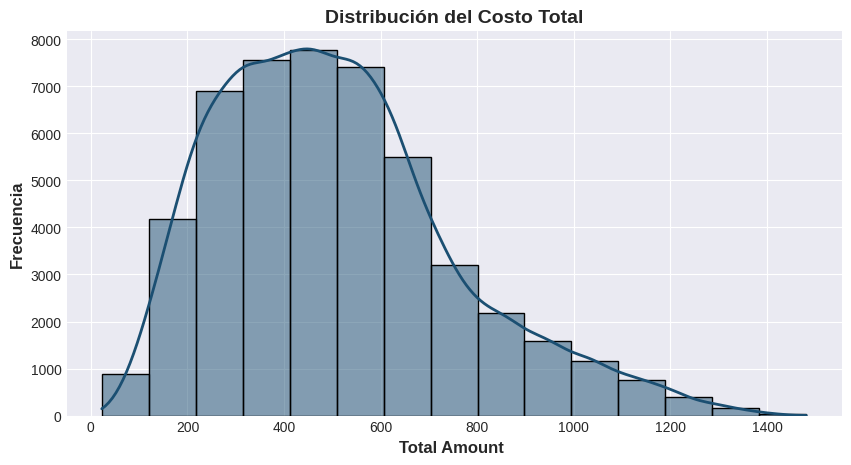

In [ ]:
# Histograma de Costo Total de los envios
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Total Amount', bins=15, kde=True)
plt.title('Distribución del Costo Total')
plt.xlabel('Total Amount ')
plt.ylabel('Frecuencia')
plt.show()

La distribución del Costo Total presenta un sesgo marcado hacia la derecha, con una alta concentración de envíos en rangos de costo bajo y una cola larga de valores elevados.
Este patrón indica que la mayoría de las operaciones logísticas se mantienen dentro de un rango de costos estándar, mientras que un número reducido de envíos genera montos significativamente más altos, típicos de operaciones de larga distancia, pesos grandes o servicios especiales.

Este comportamiento es frecuente en variables financieras, donde predominan los valores pequeños y las operaciones excepcionales elevan la cola derecha.

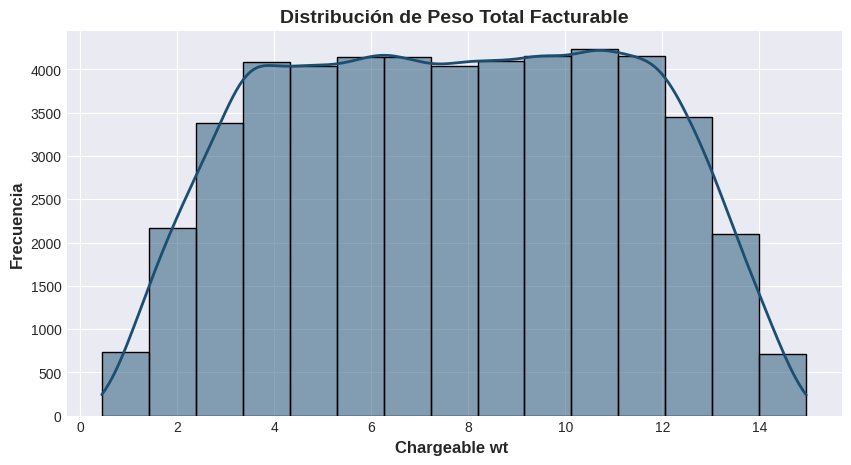

In [ ]:
# Histograma de peso total facturable
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Chargeable Wt', bins=15, kde=True)
plt.title('Distribución de Peso Total Facturable')
plt.xlabel('Chargeable wt ')
plt.ylabel('Frecuencia')
plt.show()

La distribución del peso facturable muestra un patrón estable y concentrado en rangos medios, con valores típicos entre 4 y 12 kg.
La curva presenta una forma prácticamente unimodal y relativamente simétrica, lo que indica que la mayoría de los envíos operan en pesos moderados sin una presencia fuerte de extremos.

Existe una meseta central amplia, que sugiere consistencia en el tipo de carga transportada y un perfil operativo homogéneo. Aunque aparecen algunos envíos más livianos o más pesados (hasta 15 kg), estos representan una proporción menor y no alteran significativamente el comportamiento general.

Insight clave: la empresa maneja un volumen mayoritario de envíos de peso medio, lo que facilita la estandarización de tarifas, embalajes y capacidad operativa, y permite construir modelos predictivos más estables al tratarse de una variable con baja variabilidad extrema.

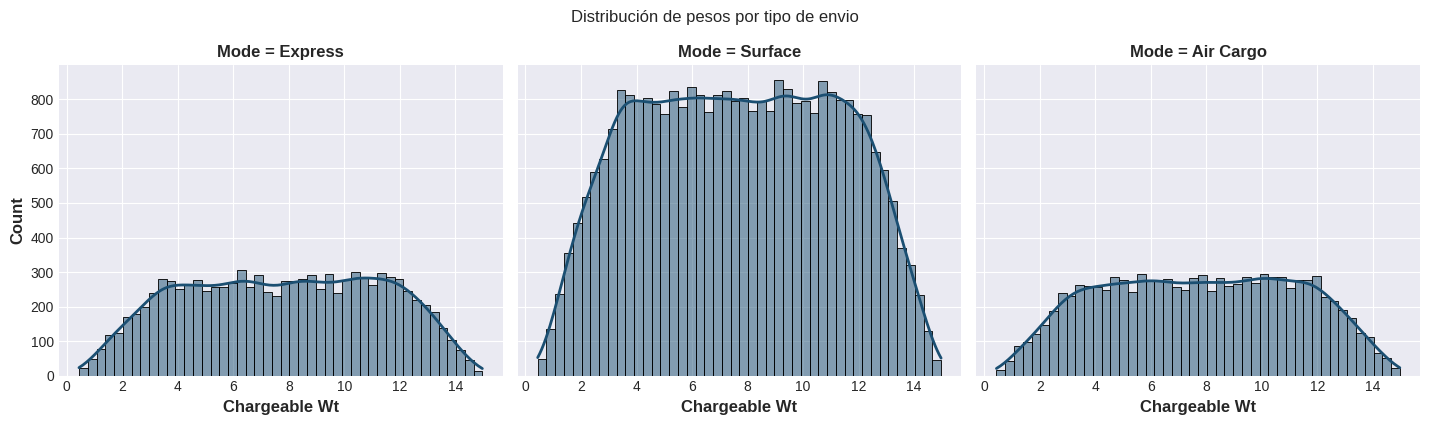

In [ ]:
# Displot: Distribución de pesos por tipo de envio
sns.displot(data=df, x='Chargeable Wt', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de pesos por tipo de envio', y=1.05)
plt.show()

La distribución del peso facturable es consistente entre los tres modos de envío, con un rango operativo predominante entre 3 y 12 kg, lo que indica que la mayoría de las cargas pertenecen a un segmento de peso medio estable.

Surface es el modo dominante en volumen, lo que sugiere alta preferencia operativa para cargas no urgentes pero de peso estándar. Su distribución plana y uniforme refleja un flujo estable y estandarizado.

Tanto Express como Air Cargo replican un patrón similar, aunque con menor volumen, mostrando que el peso no es un diferenciador relevante en la elección del modo. La selección del servicio parece estar impulsada más por tiempos de entrega que por el peso mismo.

Insight clave: los tres modos comparten un perfil de carga homogéneo, lo que facilita estrategias comunes de tarificación, embalaje y capacidad operativa, y simplifica el posterior modelado de costos.

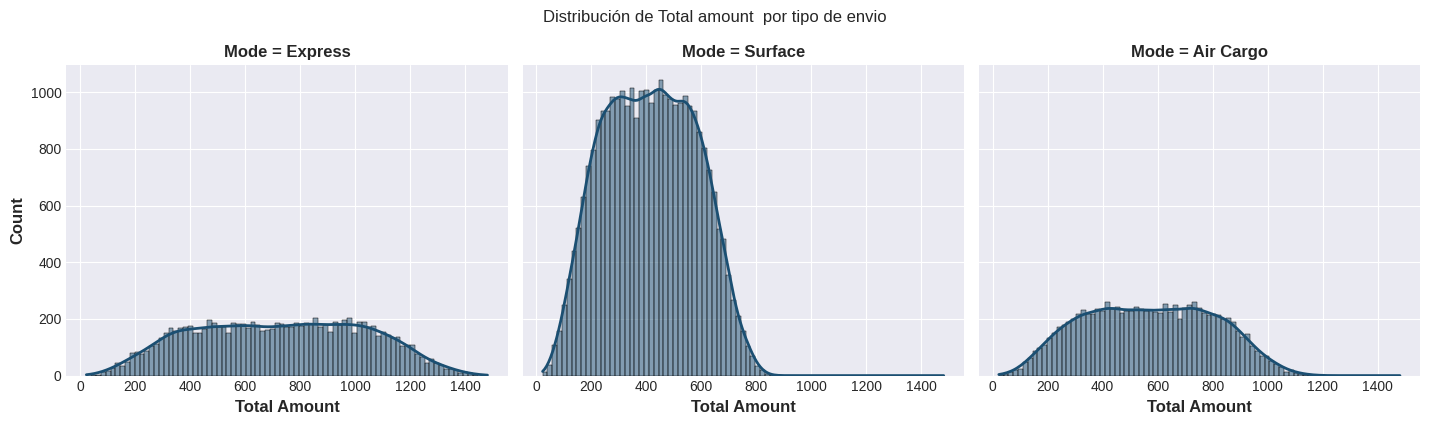

In [ ]:
# Displot: Distribución de Total amount por tipo de envio
sns.displot(data=df, x='Total Amount', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Total amount  por tipo de envio', y=1.05)
plt.show()

Express

Presenta la mayor variabilidad de montos, con un rango que se extiende aproximadamente desde 100 hasta más de 1400.
La forma de la distribución es relativamente plana en la zona media (300–800), lo que indica que Express opera con estructuras tarifarias más diversas.
Esto puede deberse a diferencias marcadas en distancia, urgencia, peso y servicios adicionales.
Insight: Express es un servicio heterogéneo y de amplia dispersión tarifaria, alineado con un posicionamiento premium y flexible.

Surface

Muestra la distribución más concentrada y estable del conjunto.
Su pico claro se ubica entre 300 y 500, con caída pronunciada más allá de los 600.
La estructura tarifaria luce más estándar, con reglas definidas y un comportamiento más predecible.
Insight: Surface es el modo más económico y masivo, ideal para optimizar costos y mantener procesos uniformes.

Air Cargo

Exhibe un volumen menor, pero con una distribución similar a Express en la franja media (400–800).
Tiene muy poca presencia de montos por encima de 900, lo que sugiere control tarifario más acotado y un segmento bien definido.
Insight: Air Cargo opera con cargas de mayor urgencia pero mantiene un rango tarifario más acotado que Express.

El modo de envío influye fuertemente en la variabilidad del costo total.
Mientras Surface ofrece una estructura tarifaria estable y predecible, Express y Air Cargo presentan mayor heterogeneidad, lo que explica por qué el mode es una variable crítica para el modelo de predicción de costos.

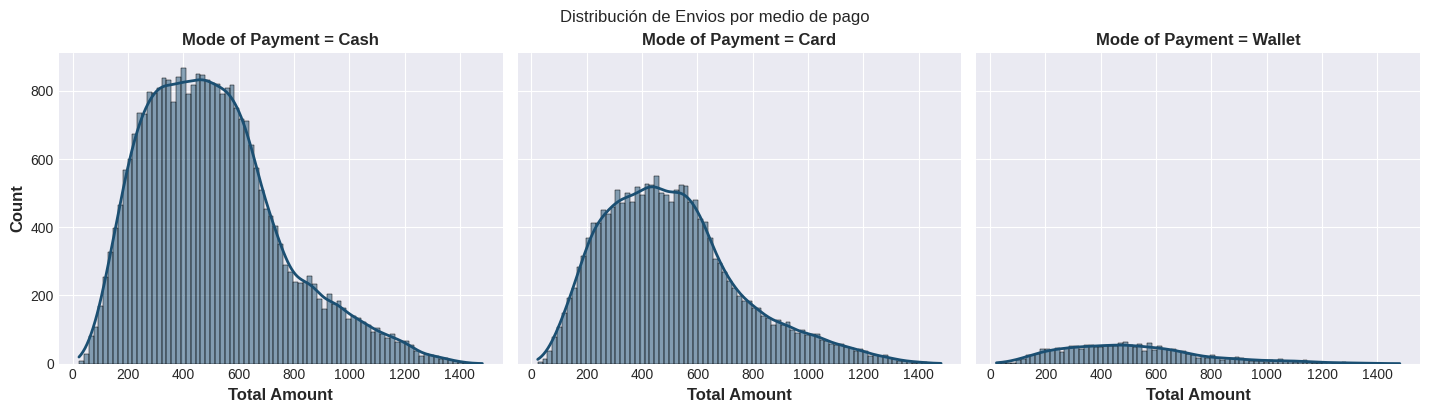

In [ ]:
# Displot: Distribución de Envios por medio de pago
sns.displot(data=df, x='Total Amount', col='Mode of Payment', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02)
plt.show()

1. Cash

Presenta la distribución más voluminosa y estable, con un pico concentrado entre 300 y 500.
La cola derecha es larga pero suave, lo cual confirma que la mayoría de los envíos pagados en efectivo corresponden a montos estándar, con pocas operaciones de alto valor.

2. Card

La forma es prácticamente idéntica a Cash, con un rango principal entre 350 y 550.
La similitud sugiere que las transacciones con tarjeta siguen el mismo patrón operativo y de costos que las realizadas en efectivo.

3. Wallet

Exhibe mucho menor volumen, pero mantiene la estructura general: concentración entre 350 y 600, con muy pocos envíos de alto costo.
La menor frecuencia posiblemente indica un uso más específico o limitado de esta modalidad.

El costo total del envío es independiente del medio de pago.
Esto refuerza que la tarifa está determinada por variables operativas —peso, distancia, urgencia, servicios adicionales— y no por la forma de pago.

Desde un enfoque de modelado, Mode of Payment podría mantenerse como variable categórica, pero se espera que su contribución al performance del modelo sea marginal.

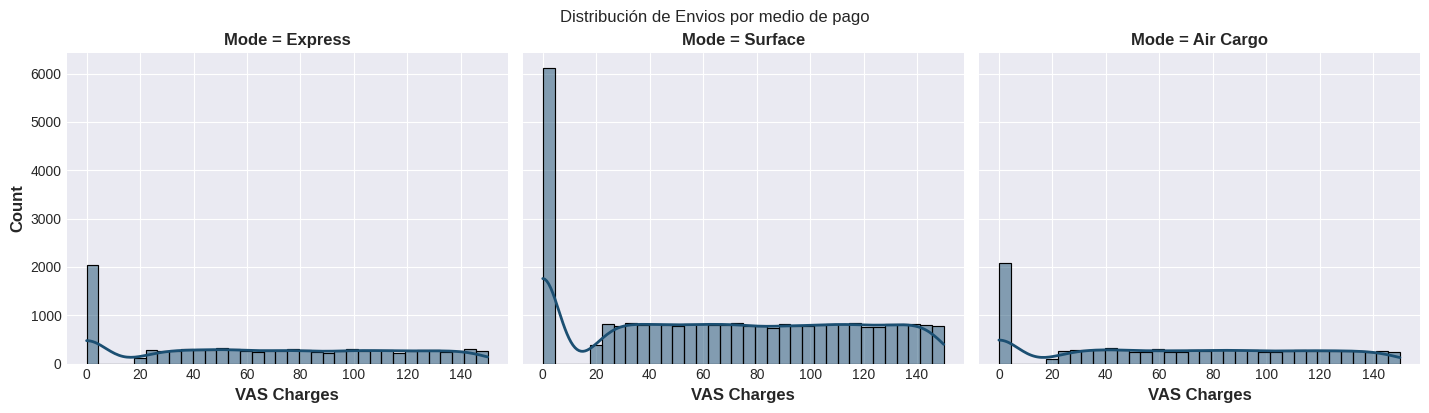

In [ ]:
# Displot: Distribución de Envios por medio de pago
sns.displot(data=df, x='VAS Charges', col='Mode', kde=True, height=4, aspect=1.2)
plt.suptitle('Distribución de Envios por medio de pago', y=1.02)
plt.show()

1. Express

Se observa un primer bloque muy alto de casos con VAS = 0, seguido de una distribución baja pero estable entre 20 y 150.
Esto sugiere que, aunque Express permite agregar servicios adicionales, no son parte del uso habitual por parte de los clientes.

2. Surface

Exhibe el mismo comportamiento, pero con mayor volumen absoluto debido a que Surface es el modo más utilizado.
La forma es casi idéntica a Express, reforzando que el uso de servicios adicionales no depende del modo de envío.

3. Air Cargo

Aunque con menos envíos totales, la distribución es igual: gran mayoría con VAS = 0 y resto disperso en valores intermedios.
No hay evidencia de que Air Cargo incorpore más servicios premium a pesar de ser un modo asociado a urgencia.


El componente VAS (Value Added Services) no es un driver principal del costo.
La mayoría de los envíos no contrata servicios adicionales, y cuando ocurren, los montos no siguen un patrón dependiente del modo de envío.

Para modelos de Machine Learning, esto significa que VAS Charges será una variable de bajo peso predictivo excepto en casos puntuales, y su distribución sesgada (muchos ceros + cola extendida) debe considerarse como una variable altamente esparsa.

# **Identificacion y tratamiento de outliers**

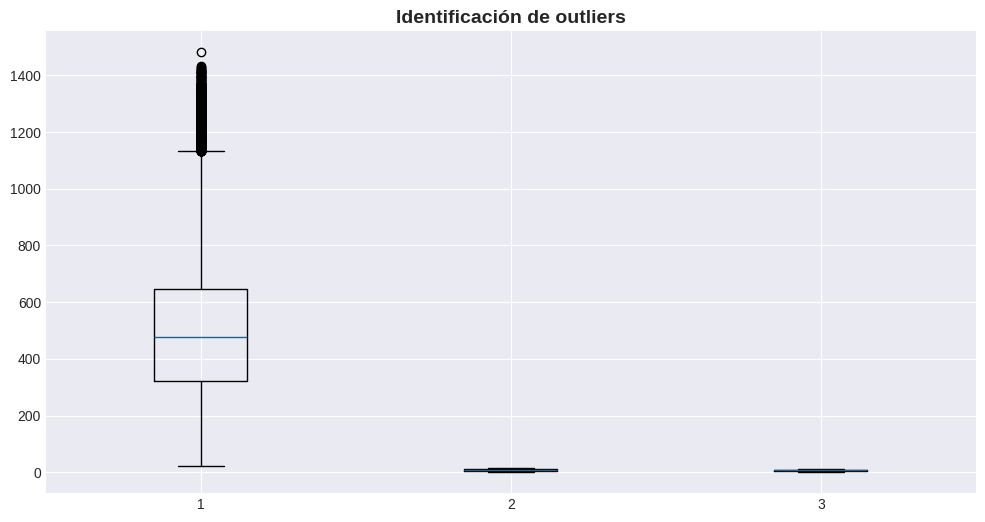

In [ ]:
# Identificar outliers con boxplot

plt.boxplot([df['Total Amount'], df['Chargeable Wt'], df['Actual Wt']])
plt.title('Identificación de outliers')

plt.show()


Al analizar los tres boxplots en conjunto, podemos identificar varios patrones importantes
sobre los valores atípicos en nuestros datos:

**Total Amount (Costo Total):**
- Presenta la mayor cantidad de outliers superiores, con valores que se extienden
  considerablemente por encima del límite superior
- Estos outliers representan envíos de costo excepcionalmente alto, probablemente
  combinaciones de: paquetes muy pesados + largas distancias + servicios premium
- La presencia de estos valores atípicos es esperada en logística, donde ocasionalmente
  se manejan envíos especiales de alto valor

**Chargeable Wt y Actual Wt (Pesos):**
- Ambas variables muestran distribuciones más compactas con menos outliers extremos
- Los outliers que aparecen en pesos están relacionados con cargas inusualmente pesadas
- La similitud entre ambos boxplots confirma que el peso volumétrico raramente excede
  el peso real en esta muestra

**Implicación práctica:**
Los outliers en costos no siempre corresponden a outliers en peso, lo que sugiere que
otros factores (distancia, tipo de servicio, cargos adicionales) también influyen
significativamente en el costo final. Esto justifica mantener estos valores en el
análisis en lugar de eliminarlos, ya que representan casos de negocio reales y valiosos.

In [ ]:
num_cols = ["Actual Wt", "Chargeable Wt", "Total Amount"]

for col in num_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR

        outliers_bajos = (df[col] < low).sum()
        outliers_altos = (df[col] > high).sum()
        total_outliers = outliers_bajos + outliers_altos
        porcentaje = (total_outliers / len(df)) * 100

        print(f"\n {col}:")
        print(f"   Outliers por debajo: {outliers_bajos}")
        print(f"   Outliers por encima: {outliers_altos}")
        print(f"    TOTAL: {total_outliers} ({porcentaje:.2f}%)")



 Actual Wt:
   Outliers por debajo: 0
   Outliers por encima: 0
    TOTAL: 0 (0.00%)

 Chargeable Wt:
   Outliers por debajo: 0
   Outliers por encima: 0
    TOTAL: 0 (0.00%)

 Total Amount:
   Outliers por debajo: 0
   Outliers por encima: 1011
    TOTAL: 1011 (2.04%)


In [ ]:
# Investigar los outliers


# Calcular límites
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
high = Q3 + 1.5 * IQR

# Filtrar solo los outliers
outliers = df[df['Total Amount'] > high].copy()

print("="*70)
print(" CARACTERÍSTICAS DE LOS OUTLIERS EN TOTAL AMOUNT")
print("="*70)
print(f"\nTotal de outliers: {len(outliers)}")
print(f"\nEstadísticas de Total Amount en outliers:")
print(outliers['Total Amount'].describe())

print(f"\n Distribución por Modo de Envío:")
print(outliers['Mode'].value_counts())

print(f"\n Estadísticas de Peso:")
print(f"Peso promedio (outliers): {outliers['Chargeable Wt'].mean():.2f}")
print(f"Peso promedio (normal): {df[df['Total Amount'] <= high]['Chargeable Wt'].mean():.2f}")

print(f"\n Distancia:")
print(f"Distancia promedio (outliers): {outliers['Distance_km'].mean():.2f}")
print(f"Distancia promedio (normal): {df[df['Total Amount'] <= high]['Distance_km'].mean():.2f}")

# Ver algunos ejemplos
print(f"\n Ejemplos de outliers:")
print(outliers[['Total Amount', 'Chargeable Wt', 'Distance_km', 'Mode']].head(10))
print("="*70)

 CARACTERÍSTICAS DE LOS OUTLIERS EN TOTAL AMOUNT

Total de outliers: 1011

Estadísticas de Total Amount en outliers:
count    1011.000000
mean     1220.025213
std        69.319333
min      1131.740000
25%      1163.020000
50%      1203.340000
75%      1265.480000
max      1481.160000
Name: Total Amount, dtype: float64

 Distribución por Modo de Envío:
Mode
Express      1005
Air Cargo       6
Name: count, dtype: int64

 Estadísticas de Peso:
Peso promedio (outliers): 13.00
Peso promedio (normal): 7.61

 Distancia:
Distancia promedio (outliers): 1097.23
Distancia promedio (normal): 1085.11

 Ejemplos de outliers:
     Total Amount  Chargeable Wt  Distance_km     Mode
3         1187.23          14.44   993.698924  Express
116       1200.62          12.48   844.376599  Express
119       1210.23          12.48  2080.944161  Express
130       1327.77          12.87   998.423977  Express
208       1189.93          13.43   825.003081  Express
318       1235.07          13.76  1302.115681  Expr

 No son errores, son **reales** (especiales:envios Express muy caros)porque:

1) Los pesos son lógicos (12-14 kg, no 1000 kg)

2) Las distancias son normales (800-1100 km)

3) El modo Express explica el costo alto

4) No hay valores absurdos

Decidimos transformarlos no eliminarlos para mantener todos los datos y que el modelo pueda predecir todos los envios, incluso aquellos mas caros

In [ ]:
# Transformacion logaritmica


# Análisis de outliers
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
high = Q3 + 1.5 * IQR

outliers = ((df['Total Amount'] > high)).sum()
print(f" Outliers detectados: {outliers} ({(outliers/len(df)*100):.2f}%)")
print("Estrategia: Transformación logarítmica (mantiene datos)")

# Crear log
df['log_total_amount'] = np.log(df['Total Amount'] + 1)
print(f" log_total_amount creado")


 Outliers detectados: 1011 (2.04%)
Estrategia: Transformación logarítmica (mantiene datos)
 log_total_amount creado


Total Amount original - Min: 22.63, Max: 1481.16
Log Total Amount - Min: 3.16, Max: 7.30


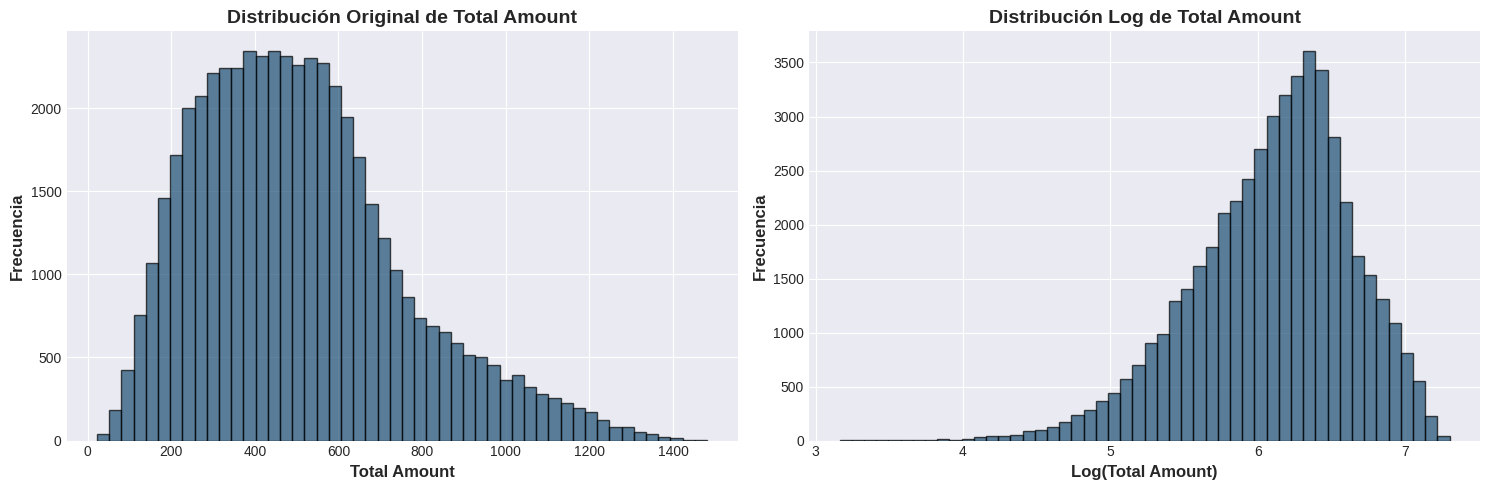

In [ ]:
print(f"Total Amount original - Min: {df['Total Amount'].min():.2f}, Max: {df['Total Amount'].max():.2f}")
print(f"Log Total Amount - Min: {df['log_total_amount'].min():.2f}, Max: {df['log_total_amount'].max():.2f}")

# Visualizar la transformación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribución original
ax1.hist(df['Total Amount'], bins=50, alpha=0.7,edgecolor='black')
ax1.set_title('Distribución Original de Total Amount')
ax1.set_xlabel('Total Amount')
ax1.set_ylabel('Frecuencia')

# Distribución logarítmica
ax2.hist(df['log_total_amount'], bins=50, alpha=0.7, edgecolor='black')
ax2.set_title('Distribución Log de Total Amount')
ax2.set_xlabel('Log(Total Amount)')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Distribución Original (izquierda)

La variable Total Amount presenta una asimetría marcada hacia la derecha, con la mayoría de los envíos concentrados en rangos entre 200 y 600, y una cola extendida que alcanza valores cercanos a 1500.
Este comportamiento es típico en variables financieras, donde existen pocas operaciones de alto costo que distorsionan la escala.

Implicación analítica:
La presencia de valores extremos puede afectar la estabilidad de los modelos predictivos, incrementando la varianza y reduciendo la capacidad de generalización.

Distribución Transformada en Log (derecha)

Tras aplicar la transformación logarítmica, la distribución se vuelve más simétrica y cercana a una normal, reduciendo la dispersión generada por operaciones de gran monto.
La transformación “comprime” los valores altos y estabiliza la escala, permitiendo que el modelo trate todos los casos con pesos más equilibrados.

Implicación analítica:
Este ajuste mejora significativamente el comportamiento de algoritmos sensibles a la escala, especialmente modelos lineales y técnicas basadas en distancia. También ayuda a reducir el impacto de outliers en el proceso de entrenamiento.


La transformación logarítmica optimiza la capacidad del modelo para capturar relaciones reales entre las variables y mejora la calidad de las predicciones, al eliminar el sesgo que generan los envíos de alto valor.
Esto deja la variable lista para ser utilizada como target del modelo con mayor estabilidad y desempeño.

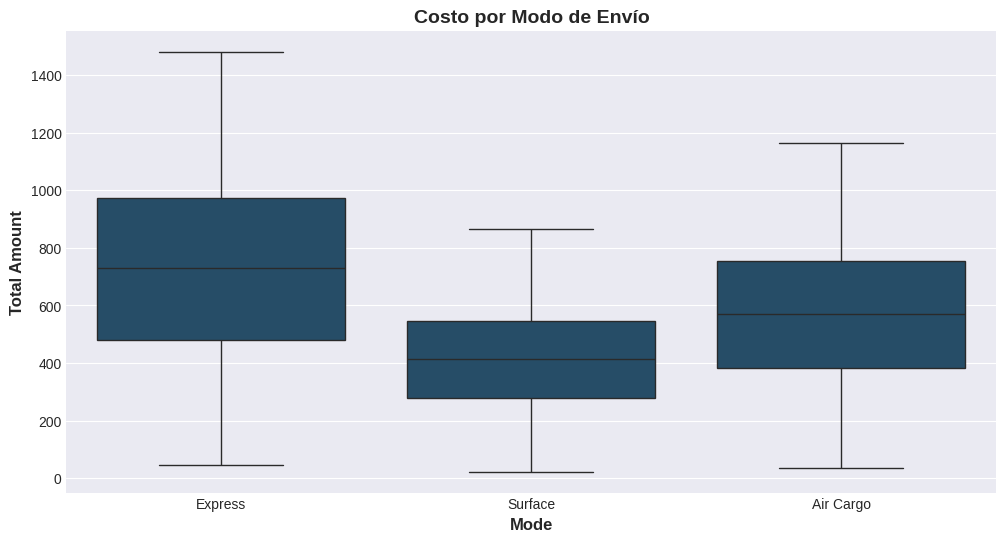

In [ ]:
# Boxplot de "Total Amount" por "Mode"
sns.boxplot(x="Mode", y="Total Amount", data=df)
plt.title("Costo por Modo de Envío")
plt.show()

El gráfico evidencia diferencias claras en el comportamiento del costo total entre los tres modos de envío.

Express

Es la modalidad más costosa y con mayor variabilidad.
Presenta una mediana alta y un rango extremadamente amplio, lo que refleja servicios de urgencia, distancias diversas y estructuras tarifarias más flexibles.
Insight: Express funciona como un servicio premium con precios altamente sensibles a las características del envío.

Surface

Es la alternativa más económica y estable.
Su mediana baja y su dispersión reducida muestran que opera con reglas tarifarias más uniformes y con un perfil de carga más homogéneo.
Insight: Surface es el núcleo operativo de bajo costo, ideal para volúmenes altos y rutas regulares.

Air Cargo

Se ubica en un segmento intermedio: más caro que Surface pero menos volátil que Express.
Su dispersión moderada refleja operaciones urgentes pero con un esquema tarifario más controlado.
Insight: Air Cargo es una opción balanceada entre urgencia y costo.

El modo de envío es un determinante crítico del costo logístico.
Surface es claramente la opción más accesible y predecible; Air Cargo mantiene un costo medio con variabilidad acotada; y Express presenta la mayor dispersión y los precios más altos.

Estas diferencias justifican fuertemente incluir el Mode como variable esencial en el modelo de predicción de costos.

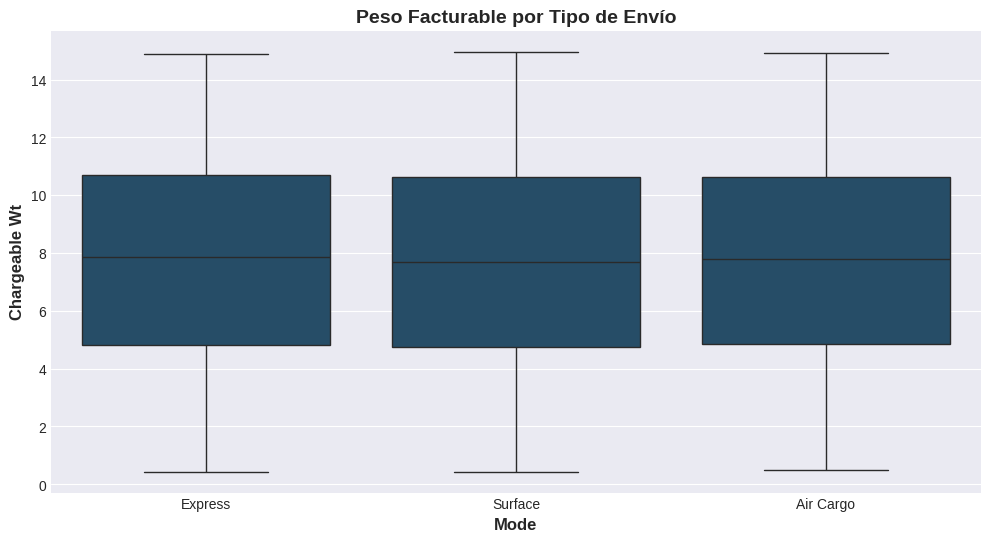

In [ ]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="Chargeable Wt", data=df)
plt.title("Peso Facturable por Tipo de Envío")
plt.show()

La distribución del peso facturable es prácticamente idéntica en las tres modalidades (Express, Surface y Air Cargo).
Las medianas y rangos intercuartílicos son casi iguales, lo que indica que el peso no es un factor determinante en la elección del modo de transporte.

Hallazgos clave

Homogeneidad total: los tres modos manejan cargas muy similares, con pesos típicos entre 5 y 10 kg, sin diferencias operativas relevantes.

Amplio rango natural: los valores se distribuyen aproximadamente entre 0 y 15 kg, pero de manera consistente en los tres casos.

Ausencia de outliers visibles: no se observan valores extremadamente alejados; los bigotes representan el rango natural de operación.

Insight operativo: la decisión del cliente de usar Express, Surface o Air Cargo no depende del peso, sino de factores como urgencia o tipo de servicio.

El peso no segmenta los modos de envío.
Esto significa que en el modelo predictivo, Mode explica variaciones de costo y tiempo, pero no actúa como función del peso, lo cual simplifica la ingeniería del modelo y confirma que ambas variables aportan información complementaria.

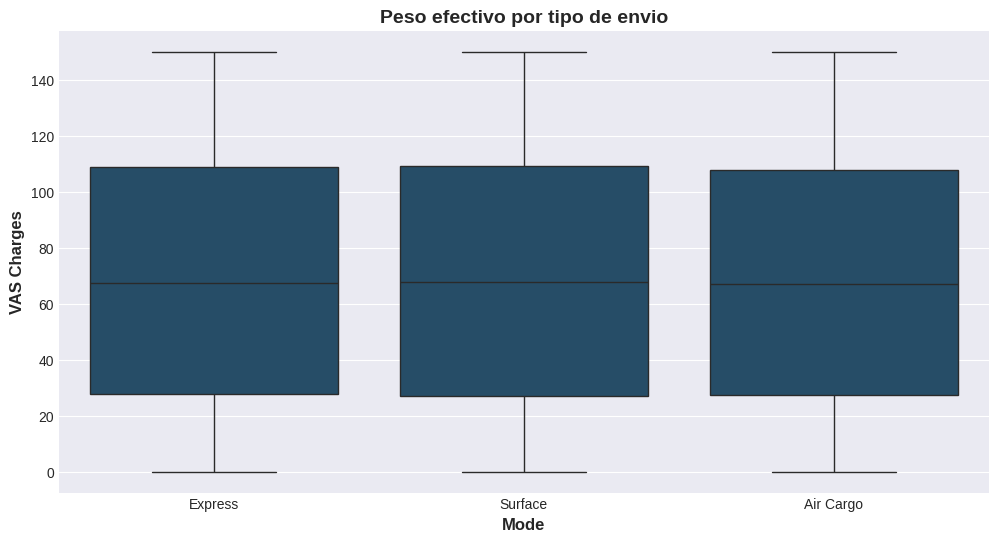

In [ ]:
# Boxplot de "Chargeable Wt" por "Mode"
sns.boxplot(x="Mode", y="VAS Charges", data=df)
plt.title("Peso efectivo por tipo de envio")
plt.show()

1. Homogeneidad total entre los modos

Las tres modalidades presentan distribuciones prácticamente idénticas en términos de mediana, rango y dispersión.
La mediana de los cargos adicionales se ubica alrededor de 65–70 en los tres casos, con bigotes que llegan aproximadamente a 0 por abajo y 150 por arriba.

Insight: El modo de envío no influye en los cargos por servicios adicionales, lo que indica que los VAS tienen un comportamiento independiente del canal logístico.

2. Amplio rango natural pero sin outliers evidentes

Aunque los bigotes abarcan valores de 0 a 150, no se observan puntos extremos adicionales que indiquen anomalías.
Esto muestra que los VAS siguen un rango amplio pero estable en todas las modalidades.

3. Uso de VAS transversal en toda la operación

La similitud entre las tres cajas indica que los servicios adicionales no se usan más en Express ni menos en Surface o Air Cargo.
Independientemente de la urgencia o el tipo de envío, los clientes agregan servicios especiales con un patrón comparable.

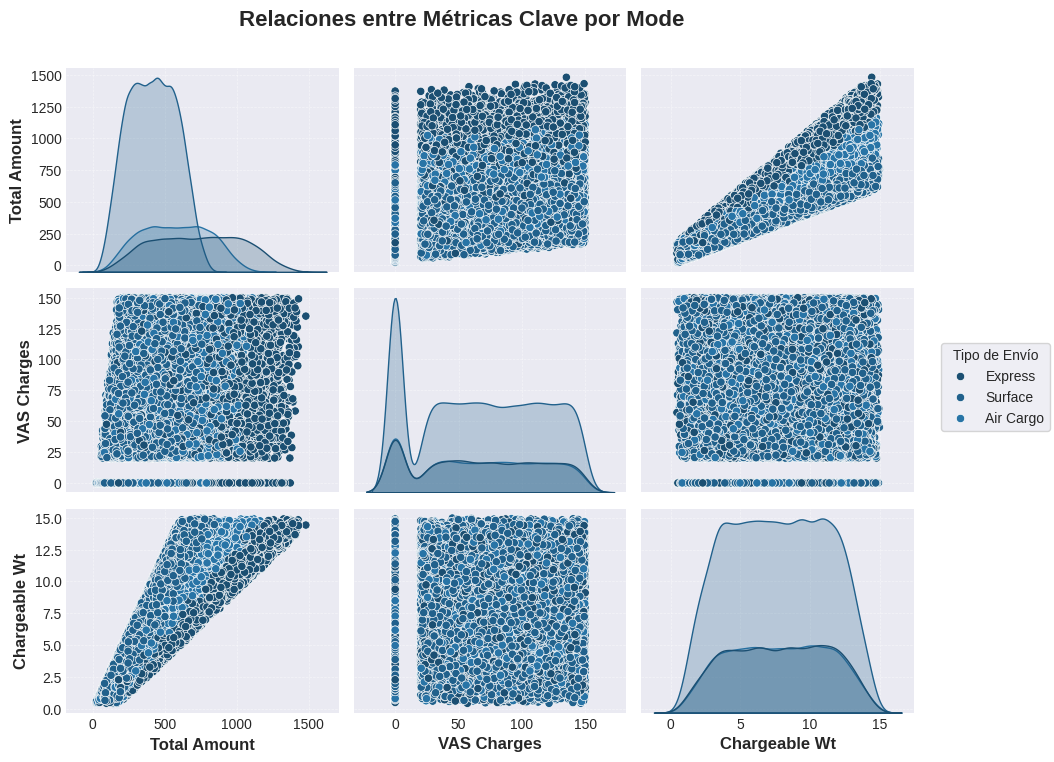

In [ ]:
# Pairplot para visión general
columnas_pairplot = ['Total Amount', 'Mode', 'VAS Charges','Chargeable Wt']
g = sns.pairplot(df[columnas_pairplot], hue='Mode', height=2.5, aspect=1.1)

# Configurar leyenda
g._legend.set_bbox_to_anchor((1.0, 0.5))
g._legend.set_loc('center left')
g._legend.set_title('Tipo de Envío')
g._legend.set_frame_on(True)

# Grid en todos los subplots
for ax in g.axes.flatten():
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

# Título general
plt.suptitle('Relaciones entre Métricas Clave por Mode', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

1. Relación fuerte entre Costo Total y Peso Facturable

La diagonal inferior izquierda muestra una tendencia claramente ascendente:
a mayor peso, mayor costo total.
Esta relación es casi triangular, confirmando que el peso es uno de los principales determinantes del costo.

Insight:
El Chargeable Weight es un predictor clave para el modelo, con impacto directo y consistente en el costo.

2. VAS Charges no guarda relación clara con el Costo Total

Las gráficas entre Total Amount y VAS Charges muestran un patrón totalmente disperso, sin forma ni pendiente definida.
La nube es homogénea en todo el rango.

Insight:
Los servicios adicionales se cobran de forma independiente del costo base del envío y no explican variaciones relevantes en el monto total.

3. VAS Charges tampoco se relaciona con el Peso

La dispersión entre VAS Charges y Chargeable Wt es completamente uniforme.
No hay patrones, agrupamientos ni tendencia lineal.

Insight:
Los VAS no dependen de si el envío es más liviano o más pesado; parecen activarse por requerimientos del cliente, no por características físicas del envío.

4. Distributions individuales confirman patrones previos

Total Amount → muy sesgado a la derecha.

VAS Charges → gran masa en valores bajos y dispersión sin estructura.

Chargeable Wt → distribución amplia y relativamente uniforme.

Insight:
Las tres variables operan en escalas y comportamientos distintos, lo que aporta valor informativo al modelo sin redundancias fuertes.



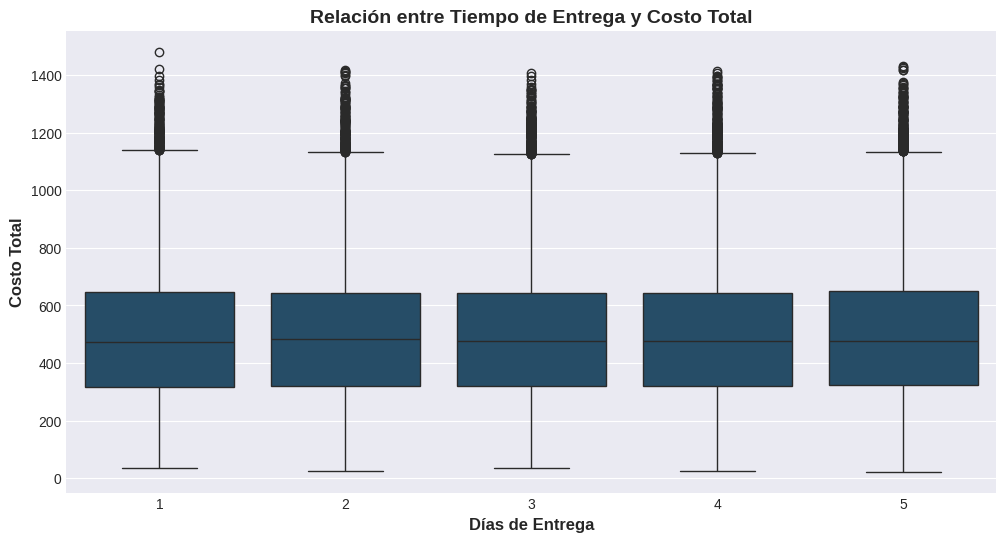

In [ ]:
# 'Tiempo_Entrega' (días reales que tomó el envío)
# +1 para evitar ceros si se entrega el mismo día
df['Delivery_Days'] = (df['Receive Date'] - df['Sender Date']).dt.days
df.loc[df['Delivery_Days'] < 0, 'Delivery_Days'] = 0 # Corrección por si acaso

# Boxplot para ver la distribución de costos según los días que tardó
sns.boxplot(x='Delivery_Days', y='Total Amount', data=df)

plt.title('Relación entre Tiempo de Entrega y Costo Total')
plt.xlabel('Días de Entrega')
plt.ylabel('Costo Total')

plt.show()

El análisis muestra que el costo total se mantiene relativamente estable independientemente del número de días de entrega.
Las medianas entre 1 y 5 días son muy similares, lo que indica que el tiempo de entrega no es un determinante directo del costo en este modelo operativo.

Si bien se observan outliers en todos los grupos —principalmente envíos de alto valor o larga distancia— estos no están concentrados en un día particular, sino que se distribuyen de forma homogénea.

Insight clave: el costo parece estar más asociado a factores intrínsecos del envío (peso, distancia, tipo de carga o servicios adicionales) que al tiempo de entrega. Esto sugiere oportunidades para optimizar precios sin comprometer tiempos, reforzando estrategias de eficiencia operativa.

## **Mapa Interactivo**

In [ ]:
#CREACION DE COLUMNAS DE COORDENADAS

def extract_lat(x):
    return x[0] if isinstance(x, tuple) and len(x) == 2 else np.nan

def extract_lon(x):
    return x[1] if isinstance(x, tuple) and len(x) == 2 else np.nan

# Coordenadas de Origen y Destino
df['Lat_Orig'] = df['Coords_Origin'].apply(extract_lat)
df['Lon_Orig'] = df['Coords_Origin'].apply(extract_lon)
df['Lat_Dest'] = df['Coords_Dest'].apply(extract_lat)
df['Lon_Dest'] = df['Coords_Dest'].apply(extract_lon)

# Filtramos solo filas con ambas coordenadas válidas
df_routes = df.dropna(
    subset=['Lat_Orig', 'Lon_Orig', 'Lat_Dest', 'Lon_Dest']
).copy()


In [ ]:

#  Preparar métricas por ciudad

grouped = df_routes.groupby('Origin').agg(
    mean_amount=('Total Amount', 'mean'),
    count_routes=('Destination', 'count'),
    unique_dest=('Destination', 'nunique'),
).reset_index()

# modos por ciudad
mode_dist = (
    df_routes.groupby(['Origin', 'Mode'])
    .size()
    .unstack(fill_value=0)
)

# merge
city_stats = grouped.merge(mode_dist, left_on='Origin', right_index=True)



#  MAPA BASE
m = Map(
    center=(22.9734, 78.6569),
    zoom=5,
    basemap={'url': 'https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png'},
    layout=Layout(width="900px", height="650px")
)

# Paleta corporativa
mode_colors = {
    'Express': '#004C99',
    'Surface': '#3A7CA5',
    'Air Cargo': '#7FB3D5'
}


# Rutas agrupadas por ciudad
routes_groups = {}
coords_by_origin = {}

for origin, g in df_routes.groupby('Origin'):
    lat0 = g['Lat_Orig'].iloc[0]
    lon0 = g['Lon_Orig'].iloc[0]
    coords_by_origin[origin] = (lat0, lon0)

    # Crear líneas de rutas
    polylines = []
    for _, row in g.iterrows():
        color = mode_colors.get(row['Mode'], '#2B8CBE')
        pl = Polyline(
            locations=[(row['Lat_Orig'], row['Lon_Orig']),
                       (row['Lat_Dest'], row['Lon_Dest'])],
            color=color,
            weight=2,
            opacity=0.6
        )
        polylines.append(pl)

    routes_groups[origin] = LayerGroup(layers=polylines)


#  Función para hover + popup
def attach_hover(circle, origin, group, mapa):

    stats = city_stats[city_stats['Origin'] == origin].iloc[0]

    # Tooltip: resumen rápido
    tooltip_text = (
        f"{origin}\n"
        f"Promedio $: {stats['mean_amount']:.0f}\n"
        f"Destinos únicos: {stats['unique_dest']}\n"
    )

    circle.tooltip = tooltip_text

    # Popup detallado
    popup_html_content = f"""
    <b>{origin}</b><br>
    Promedio Total Amount: {stats['mean_amount']:.2f}<br>
    Envíos totales: {stats['count_routes']}<br>
    Destinos únicos: {stats['unique_dest']}<br>
    <br><b>Modos utilizados:</b><br>
    """
    for mode in ['Express', 'Surface', 'Air Cargo']:
        if mode in stats:
            popup_html_content += f"{mode}: {stats[mode]}<br>"

    # Wrap the HTML string in an ipywidgets.HTML widget
    circle.popup = HTML(popup_html_content)

    # Eventos hover
    def handle_mouseover(**kwargs):
        if group not in mapa.layers:
            mapa.add_layer(group)

    def handle_mouseout(**kwargs):
        if group in mapa.layers:
            mapa.remove_layer(group)

    circle.on_mouseover(handle_mouseover)
    circle.on_mouseout(handle_mouseout)



# TOP 3 DESTINOS POR IMPORTE
dest_stats = (
    df_routes
    .groupby(['Origin', 'Destination'])['Total Amount']
    .sum()
    .reset_index()
)

top_dest_dict = {}

for origin, g in dest_stats.groupby('Origin'):
    g_sorted = g.sort_values('Total Amount', ascending=False).head(3)
    top_dest_dict[origin] = list(
        zip(g_sorted['Destination'], g_sorted['Total Amount'])
    )
for origin, (lat, lon) in coords_by_origin.items():
    circle = CircleMarker(
        location=(lat, lon),
        radius=8,
        color="orange",
        fill_color="orange",
        fill_opacity=0.9
    )
    m.add_layer(circle)
    attach_hover(circle, origin, routes_groups[origin], m)

m





Map(center=[22.9734, 78.6569], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

**Análisis Geoespacial:** El mapa interactivo nos permite visualizar la logística de la empresa. Se observa una alta densidad de operaciones conectando los principales centros urbanos (Delhi, Mumbai, Bangalore), lo que sugiere que la red está optimizada para rutas troncales. Sin embargo, la dispersión hacia zonas periféricas indica oportunidades para optimizar la "última milla" en regiones menos conectadas.

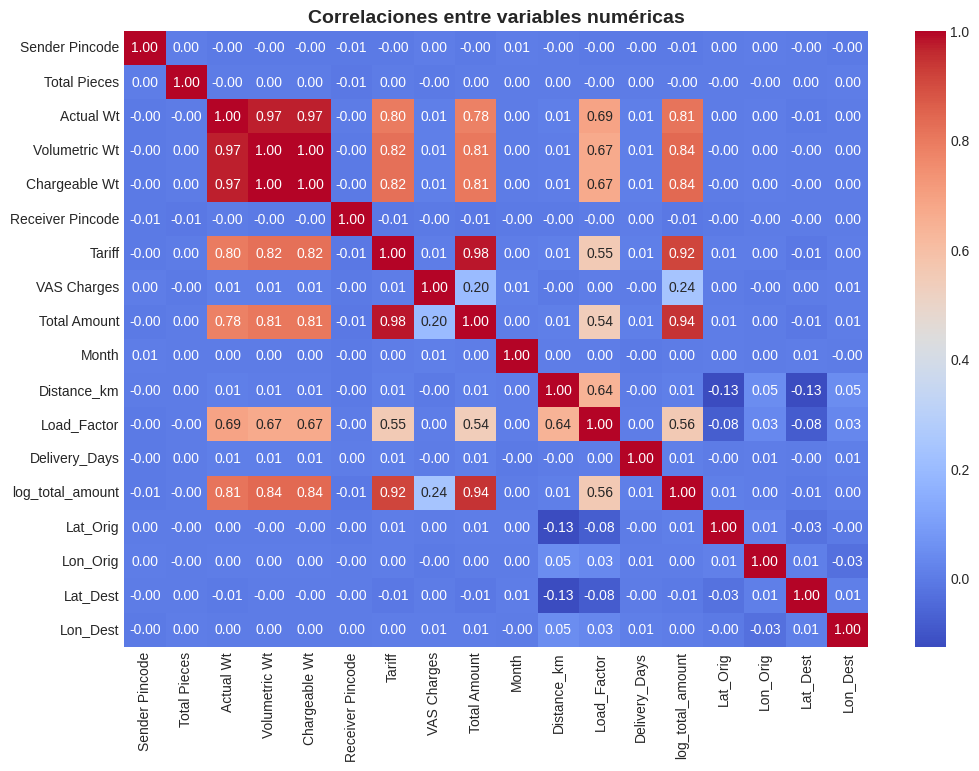

In [ ]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre variables numéricas")
plt.show()

1. Peso y volumen están fuertemente correlacionados entre sí (0.97–1.00)

Actual Weight, Volumetric Weight y Chargeable Weight forman un bloque con correlaciones muy altas.
Esto indica que representan esencialmente la misma información física del envío.

Insight:
Para evitar multicolinealidad, alcanza con incluir una sola de estas variables en el modelo (la mejor candidata suele ser Chargeable Weight).

2. El costo total tiene relaciones muy fuertes con peso, volumen y tarifa

Total Amount correlaciona:

0.78–0.84 con pesos

0.98 con Tariff

0.54 con distancia

Su versión transformada (log_total_amount) mantiene el mismo patrón.

Insight:
El costo está explicado principalmente por:

Peso facturable

Tarifa aplicada

Distancia

Estos serán los drivers principales del modelo predictivo.

3. Los VAS Charges no tienen correlación significativa

Su correlación con otras variables ronda entre 0.00 y 0.24, extremadamente baja.

Insight:
Los servicios adicionales operan como un componente aislado.
Aportan poca capacidad explicativa y probablemente tengan bajo peso en el modelo.

4. El Month, los días de entrega y los códigos postales no aportan relación estructural

Correlaciones cercanas a 0.00 indican:

No hay estacionalidades marcadas.

Los tiempos de entrega no dependen del peso ni del costo.

Los códigos postales no influyen linealmente en estas métricas.

Insight:
Estas variables pueden seguir estando en el modelo, pero su impacto será bajo.
Pueden aportar segmentación, no relación directa.

5. Distancia y Load Factor aportan información complementaria

Distance_km correlaciona con Total Amount (0.54)
Load Factor correlaciona con pesos y costos (0.55–0.69)

Insight:
Ambas variables enriquecen la explicación del costo desde dimensiones operativas distintas (distancia versus “esfuerzo logístico”).

 **Variables a incluir:**

Total Amount ~ Chargeable Wt + Mode + VAS Charges + Mode:Chargeable Wt

**Variables a excluir (multicolinealidad):**

 Actual Wt y Volumetric Wt (usar solo Chargeable Wt)

Tariff (r=0.98 con Total Amount - casi la misma variable)

Text(0.5, 1.02, 'Análisis de Features Engineered')

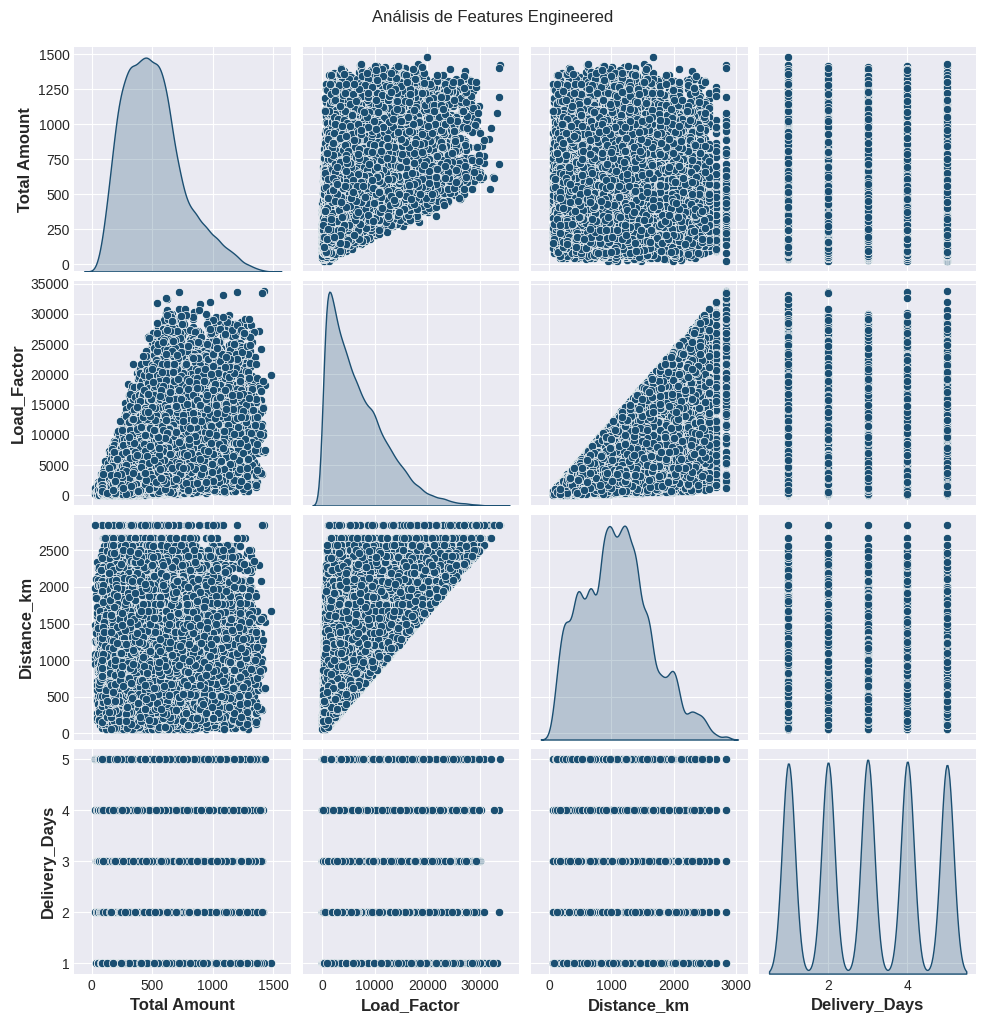

In [ ]:
# 1. Correlación de Spearman (para relaciones no lineales)
from scipy.stats import spearmanr
spearman_corr = df[['Total Amount', 'Chargeable Wt', 'Distance_km']].corr(method='spearman')

# 2. Pairplot de las nuevas variables creadas
columnas_new_features = ['Total Amount', 'Load_Factor', 'Distance_km', 'Delivery_Days']
sns.pairplot(df[columnas_new_features], diag_kind='kde')
plt.suptitle('Análisis de Features Engineered', y=1.02)

El análisis multivariado evidencia que las variables derivadas aportan estructura y explican comportamientos relevantes del costo logístico.

1. Load Factor muestra una relación creciente y consistente con Total Amount.
Esto confirma que el costo se ve influido por la combinación de peso y distancia, funcionando como un “driver compuesto” del precio. Es un buen predictor para futuros modelos de ML.

2. Distance_km presenta un gradiente positivo con el costo, aunque con mayor dispersión. El patrón sugiere que la distancia impacta, pero no de forma lineal estricta, probablemente por diferencias entre modos de envío o servicios adicionales.

3. Delivery_Days no muestra correlación directa ni tendencia con ninguna de las variables clave.
Esto refuerza el hallazgo previo: el tiempo de entrega es más un resultado operativo que un determinante del costo.

4. La distribución de Total Amount vuelve a confirmar su asimetría, validando la decisión de aplicar una transformación logarítmica para estabilizar el comportamiento.

Insight clave:
Los drivers más fuertes y estables para explicar el costo total emergen de variables físicas y operativas (peso, distancia y su combinación), mientras que el tiempo de entrega cumple un rol complementario pero no explicativo. El feature engineering realizado agrega valor real para el posterior modelado predictivo.

**# ENCODING DE VARIABLES CATEGÓRICAS**

In [ ]:

# ENCODING

# Verificar qué columnas existen
categorical_mapping = {
    'Nature of Consignment': 'Nature',
    'Mode of Payment': 'Payment',
    'Mode': 'Mode'
}

print("\n Creando variables dummy...")

for original_col, prefix in categorical_mapping.items():
    if original_col in df.columns:
        # Crear dummies
        dummies = pd.get_dummies(df[original_col], prefix=prefix, drop_first=True)

        # Agregar al dataframe
        df = pd.concat([df, dummies], axis=1)

        # Eliminar columna original
        df.drop(columns=[original_col], inplace=True)

        print(f"    {original_col} → {len(dummies.columns)} dummies creadas")

print(f"\n Dataset después de encoding: {df.shape}")

# Verificación
print("\n Verificación:")
dummy_cols = [col for col in df.columns if any(x in col for x in ['Nature_', 'Payment_', 'Mode_'])]
print(f"   Columnas dummy creadas: {len(dummy_cols)}")
if dummy_cols:
    print(f"   Ejemplos: {dummy_cols}")

categorical_remaining = df.select_dtypes(include='object').columns.tolist()
categorical_important = [col for col in categorical_remaining if col in ['Mode', 'Nature of Consignment', 'Mode of Payment']]
if categorical_important:
    print(f"     Columnas categóricas que quedaron: {categorical_important}")
else:
    print(f"   Las 3 columnas importantes fueron codificadas")

print("="*70)


 Creando variables dummy...
    Nature of Consignment → 1 dummies creadas
    Mode of Payment → 2 dummies creadas
    Mode → 2 dummies creadas

 Dataset después de encoding: (49639, 44)

 Verificación:
   Columnas dummy creadas: 5
   Ejemplos: ['Nature_Non-Dox', 'Payment_Cash', 'Payment_Wallet', 'Mode_Express', 'Mode_Surface']
   Las 3 columnas importantes fueron codificadas


El proceso de creación de variables dummy permitió transformar correctamente las columnas categóricas clave del dataset, dejándolas listas para su uso en el modelo de Machine Learning.

1. Columnas codificadas

Se generaron 5 dummies a partir de las tres variables categóricas seleccionadas:
(Nature of Consignment, Mode of Payment, Mode)

Los ejemplos muestran que se aplicó codificación de tipo one-hot encoding con eliminación de la primera categoría (drop_first=True), reduciendo la multicolinealidad.

2. Impacto en el dataset

El dataset final queda con 44 columnas, lo cual implica una ampliación razonable y manejable para modelado.

Esta expansión controla la dimensionalidad y permite capturar correctamente las variaciones entre categorías sin añadir ruido innecesario.

3. Insight ejecutivo clave

Las columnas categóricas más relevantes quedaron correctamente transformadas, garantizando que el modelo pueda interpretar diferencias entre modos de envío, medios de pago y tipo de carga.

Además:

El modo de envío es una variable de alto impacto en el costo, el medio de pago aporta información marginal (como vimos en las distribuciones), la naturaleza del envío agrega señales complementarias sobre complejidad y tratamiento.

In [ ]:
# CREACIÓN DE VARIABLES DE INTERACCIÓN

# Buscar todas las columnas que empiezan con 'Mode_'
mode_columns = [col for col in df.columns if col.startswith('Mode_')]
print(f"\nColumnas de Mode encontradas: {mode_columns}")

# Verificar que existe la columna de peso
if 'Chargeable Wt' not in df.columns:
    print(" ERROR: No se encontró la columna 'Chargeable Wt'")
elif not mode_columns:
    print(" No se encontraron columnas de Mode para crear interacciones")
else:
    # Crear interacciones: Mode × Peso
    print(f"\n Creando interacciones Mode × Chargeable Wt:")

    for mode_col in mode_columns:
        interaction_name = f'{mode_col}_Weight'

        # Verificar que no exista ya
        if interaction_name not in df.columns:
            df[interaction_name] = df[mode_col] * df['Chargeable Wt']
            print(f"   {interaction_name}")
        else:
            print(f"   {interaction_name} (ya existe)")

    print(f"\nDimensiones después de interacciones: {df.shape}")



Columnas de Mode encontradas: ['Mode_Express', 'Mode_Surface']

 Creando interacciones Mode × Chargeable Wt:
   Mode_Express_Weight
   Mode_Surface_Weight

Dimensiones después de interacciones: (49639, 46)


Estas variables de interacción capturan cómo cambia el impacto del peso según el modo de envío, permitiendo al modelo aprender diferencias tarifarias reales entre servicios premium (Express) y económicos (Surface).

## **VIF = Variance Inflation Factor (Factor de Inflación de Varianza) ( para detectar multicolinealidad)**

In [ ]:
#Analisis de multicolinealidad

df_modelo = df.copy()

#  Seleccionar solo las features que usarías en el modelo
X_features = df_modelo[['Chargeable Wt', 'VAS Charges',
                        'Mode_Express', 'Mode_Surface']].copy() # Ejemplo si Air Cargo es la base

# Convert boolean columns to integers for VIF calculation
for col in ['Mode_Express', 'Mode_Surface']:
    if col in X_features.columns and X_features[col].dtype == 'bool':
        X_features[col] = X_features[col].astype(int)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_features.columns
vif_data["VIF"] = [variance_inflation_factor(X_features.values, i)
                   for i in range(X_features.shape[1])]

# Interpretar
print(vif_data.sort_values('VIF', ascending=False))

print("\n Interpretación:")
print("VIF < 5:  No hay problema de multicolinealidad")
print("VIF 5-10:  Multicolinealidad moderada (aceptable)")
print("VIF > 10:  Multicolinealidad severa (excluir variable)")

        Variable       VIF
0  Chargeable Wt  3.462083
3   Mode_Surface  2.719782
1    VAS Charges  2.495453
2   Mode_Express  1.587256

 Interpretación:
VIF < 5:  No hay problema de multicolinealidad
VIF 5-10:  Multicolinealidad moderada (aceptable)
VIF > 10:  Multicolinealidad severa (excluir variable)


El modelo puede entrenarse de forma segura con estas variables, ya que no existe multicolinealidad severa.
Las features seleccionadas aportan señales relevantes, complementarias y estables.
Esto asegura un modelo interpretable, matemáticamente consistente y robusto.

In [ ]:
# VERIFICAR QUE EL DATAFRAME ESTÁ LISTO
print(f"DataFrame cargado: {df.shape}")
print(f"   Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"\n Columnas disponibles:")
print(df.columns.tolist())

# DEFINIR FEATURES PARA EL MODELO
numeric_features = [
    'Chargeable Wt',
    'VAS Charges',
    'Volumetric Wt',
    'Wt Actual',
    'Total Pieces'
]

categorical_features = [
    'Mode_Express',
    'Mode_Surface'
]

interaction_features = [
    'Mode_Express_Weight',
    'Mode_Surface_Weight'
]

# Combinar todas las features
all_features = numeric_features + categorical_features + interaction_features

# Variable objetivo
target = 'Total Amount'

print(f"\n FEATURES SELECCIONADAS:")
print(f"   Total: {len(all_features)} features")
print(f"   Numéricas: {len(numeric_features)}")
print(f"   Categóricas: {len(categorical_features)}")
print(f"   Interacciones: {len(interaction_features)}")
print(f"\n Variable objetivo: {target}")

# Verificar que todas las columnas existen
missing_cols = [col for col in all_features + [target] if col not in df.columns]
if missing_cols:
    print(f"\n ERROR: Columnas faltantes: {missing_cols}")
else:
    print(f"\n Todas las columnas necesarias están disponibles")

DataFrame cargado: (49639, 46)
   Filas: 49,639 | Columnas: 46

 Columnas disponibles:
['Origin', 'Destination', 'Date', 'Sender City', 'Sender State', 'Sender Pincode', 'Total Pieces', 'Actual Wt', 'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature', 'Sender Date', 'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description', 'Value Added Services', 'Expiry Date', 'Relationship', 'Receive Date', 'Tariff', 'VAS Charges', 'Total Amount', 'Risk Surcharge', 'Month', 'Is_Weekend', 'Coords_Origin', 'Coords_Dest', 'Distance_km', 'Load_Factor', 'Category_WT', 'Category_Cost', 'Delivery_Days', 'log_total_amount', 'Lat_Orig', 'Lon_Orig', 'Lat_Dest', 'Lon_Dest', 'Nature_Non-Dox', 'Payment_Cash', 'Payment_Wallet', 'Mode_Express', 'Mode_Surface', 'Mode_Express_Weight', 'Mode_Surface_Weight']

 FEATURES SELECCIONADAS:
   Total: 9 features
   Numéricas: 5
   Categóricas: 2
   Interacciones: 2

 Variable objetivo: Total Amount

 ERROR: Columnas faltantes: ['Wt Actual']


In [ ]:
# DEFINIR FEATURES PARA EL MODELO
numeric_features = [
    'Chargeable Wt',
    'VAS Charges',
    'Volumetric Wt',
    'Actual Wt',
    'Total Pieces'
]

categorical_features = [
    'Mode_Express',
    'Mode_Surface'
]

interaction_features = [
    'Mode_Express_Weight',
    'Mode_Surface_Weight'
]

# Combinar todas las features
all_features = numeric_features + categorical_features + interaction_features

# Variable objetivo
target = 'Total Amount'

print(f" FEATURES CORREGIDAS:")
print(f"   Total: {len(all_features)} features")
print(f"\n Lista completa:")
for i, feat in enumerate(all_features, 1):
    print(f"   {i}. {feat}")

print(f"\n Variable objetivo: {target}")

# Verificar que todas las columnas existen
missing_cols = [col for col in all_features + [target] if col not in df.columns]
if missing_cols:
    print(f"\n ERROR: Columnas faltantes: {missing_cols}")
else:
    print(f"\n Todas las columnas estan disponibles")

 FEATURES CORREGIDAS:
   Total: 9 features

 Lista completa:
   1. Chargeable Wt
   2. VAS Charges
   3. Volumetric Wt
   4. Actual Wt
   5. Total Pieces
   6. Mode_Express
   7. Mode_Surface
   8. Mode_Express_Weight
   9. Mode_Surface_Weight

 Variable objetivo: Total Amount

 Todas las columnas estan disponibles


In [ ]:
# PREPARAR X E Y
X = df[all_features].copy()
y = df[target].copy()

# Convertir columnas booleanas a int (si es necesario)
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

print(f" Dataset preparado:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

print(f"\n Estadísticas de la variable objetivo (Total Amount):")
print(f"   Media: ${y.mean():,.2f}")
print(f"   Mediana: ${y.median():,.2f}")
print(f"   Desviación estándar: ${y.std():,.2f}")
print(f"   Min: ${y.min():,.2f}")
print(f"   Max: ${y.max():,.2f}")

# DIVISIÓN TRAIN-TEST (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n División del dataset:")
print(f"   Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Prueba: {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

 Dataset preparado:
   X shape: (49639, 9)
   y shape: (49639,)

 Estadísticas de la variable objetivo (Total Amount):
   Media: $508.05
   Mediana: $477.64
   Desviación estándar: $248.10
   Min: $22.63
   Max: $1,481.16

 División del dataset:
   Entrenamiento: 39,711 registros (80.0%)
   Prueba: 9,928 registros (20.0%)


In [ ]:
# ESTANDARIZACIÓN DE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(" Features estandarizadas")
print(f"   Media: {X_train_scaled.mean().mean():.4f} (debe estar cerca de 0)")
print(f"   Std: {X_train_scaled.std().mean():.4f} (debe estar cerca de 1)")


print(" MODELO 1: REGRESIÓN LINEAL (BASELINE)")
print("-"*60)

# Entrenar modelo
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Métricas
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2:.4f}")
print(f"   R² Test: {test_r2:.4f}")
print(f"   RMSE Test: ${test_rmse:,.2f}")
print(f"   MAE Test: ${test_mae:,.2f}")
print(f"   MAPE Test: {test_mape:.2f}%")
print(f"   Overfitting: {train_r2 - test_r2:.4f}")



 Features estandarizadas
   Media: -0.0000 (debe estar cerca de 0)
   Std: 1.0000 (debe estar cerca de 1)
 MODELO 1: REGRESIÓN LINEAL (BASELINE)
------------------------------------------------------------

 RESULTADOS:
   R² Train: 0.9864
   R² Test: 0.9860
   RMSE Test: $29.39
   MAE Test: $22.31
   MAPE Test: 4.26%
   Overfitting: 0.0004


In [ ]:
print(" MODELO 2: RANDOM FOREST")
print("-"*60)

# Entrenar modelo (sin datos escalados, RF no lo necesita)
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n Entrenando Random Forest...")
rf_model.fit(X_train, y_train)

# Predicciones
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Métricas
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_mape_rf = mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2_rf:.4f}")
print(f"   R² Test: {test_r2_rf:.4f}")
print(f"   RMSE Test: ${test_rmse_rf:,.2f}")
print(f"   MAE Test: ${test_mae_rf:,.2f}")
print(f"   MAPE Test: {test_mape_rf:.2f}%")
print(f"   Overfitting: {train_r2_rf - test_r2_rf:.4f}")



 MODELO 2: RANDOM FOREST
------------------------------------------------------------

 Entrenando Random Forest...

 RESULTADOS:
   R² Train: 0.9949
   R² Test: 0.9846
   RMSE Test: $30.86
   MAE Test: $23.14
   MAPE Test: 4.46%
   Overfitting: 0.0103


In [ ]:
print(" MODELO 3: XGBOOST")
print("-"*60)

# Entrenar modelo
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("\n Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

# Predicciones
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Métricas
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
test_mape_xgb = mean_absolute_percentage_error(y_test, y_test_pred_xgb) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2_xgb:.4f}")
print(f"   R² Test: {test_r2_xgb:.4f}")
print(f"   RMSE Test: ${test_rmse_xgb:,.2f}")
print(f"   MAE Test: ${test_mae_xgb:,.2f}")
print(f"   MAPE Test: {test_mape_xgb:.2f}%")
print(f"   Overfitting: {train_r2_xgb - test_r2_xgb:.4f}")



 MODELO 3: XGBOOST
------------------------------------------------------------

 Entrenando XGBoost...

 RESULTADOS:
   R² Train: 0.9881
   R² Test: 0.9854
   RMSE Test: $30.06
   MAE Test: $22.69
   MAPE Test: 4.38%
   Overfitting: 0.0027


In [ ]:
print(" MODELO 4: GRADIENT BOOSTING")
print("-"*60)

# Entrenar modelo
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

print("\n Entrenando Gradient Boosting...")
gb_model.fit(X_train, y_train)

# Predicciones
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Métricas
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
test_mae_gb = mean_absolute_error(y_test, y_test_pred_gb)
test_mape_gb = mean_absolute_percentage_error(y_test, y_test_pred_gb) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2_gb:.4f}")
print(f"   R² Test: {test_r2_gb:.4f}")
print(f"   RMSE Test: ${test_rmse_gb:,.2f}")
print(f"   MAE Test: ${test_mae_gb:,.2f}")
print(f"   MAPE Test: {test_mape_gb:.2f}%")
print(f"   Overfitting: {train_r2_gb - test_r2_gb:.4f}")



 MODELO 4: GRADIENT BOOSTING
------------------------------------------------------------

 Entrenando Gradient Boosting...

 RESULTADOS:
   R² Train: 0.9875
   R² Test: 0.9855
   RMSE Test: $29.95
   MAE Test: $22.67
   MAPE Test: 4.38%
   Overfitting: 0.0020


In [ ]:
print(" COMPARACIÓN DE LOS 4 MODELOS BASE")
print("-"*60)

# Crear tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Train_R2': [train_r2, train_r2_rf, train_r2_xgb, train_r2_gb],
    'Test_R2': [test_r2, test_r2_rf, test_r2_xgb, test_r2_gb],
    'Test_RMSE': [test_rmse, test_rmse_rf, test_rmse_xgb, test_rmse_gb],
    'Test_MAE': [test_mae, test_mae_rf, test_mae_xgb, test_mae_gb],
    'Test_MAPE_%': [test_mape, test_mape_rf, test_mape_xgb, test_mape_gb],
    'Overfitting': [train_r2-test_r2, train_r2_rf-test_r2_rf,
                    train_r2_xgb-test_r2_xgb, train_r2_gb-test_r2_gb]
})

# Ordenar por R² Test
resultados = resultados.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print(resultados.to_string(index=False))
print("="*80)

print(f"\n MEJOR MODELO: {resultados.iloc[0]['Modelo']}")
print(f"   R² Test: {resultados.iloc[0]['Test_R2']:.4f}")
print(f"   RMSE: ${resultados.iloc[0]['Test_RMSE']:.2f}")
print(f"   MAPE: {resultados.iloc[0]['Test_MAPE_%']:.2f}%")

 COMPARACIÓN DE LOS 4 MODELOS BASE
------------------------------------------------------------
           Modelo  Train_R2  Test_R2  Test_RMSE  Test_MAE  Test_MAPE_%  Overfitting
Linear Regression  0.986448 0.986018  29.393932 22.314577     4.261817     0.000430
Gradient Boosting  0.987500 0.985485  29.949217 22.670224     4.380117     0.002016
          XGBoost  0.988076 0.985376  30.061331 22.687323     4.382016     0.002701
    Random Forest  0.994858 0.984585  30.863575 23.143021     4.455244     0.010273

 MEJOR MODELO: Linear Regression
   R² Test: 0.9860
   RMSE: $29.39
   MAPE: 4.26%


In [ ]:
print(" VALIDACIÓN CRUZADA (K-FOLD, k=5)")
print("-"*60)

# Definir K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelos a evaluar
modelos_cv = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

cv_resultados = {}

print("\n Ejecutando validación cruzada...\n")

for nombre, modelo in modelos_cv.items():
    # Usar datos escalados solo para Linear Regression
    if nombre == 'Linear Regression':
        X_cv = X_train_scaled
    else:
        X_cv = X_train

    # Cross-validation con R²
    scores = cross_val_score(modelo, X_cv, y_train, cv=kfold, scoring='r2', n_jobs=-1)

    cv_resultados[nombre] = {
        'Mean_R2': scores.mean(),
        'Std_R2': scores.std()
    }

    print(f" {nombre}:")
    print(f"   R² Promedio: {scores.mean():.4f} (±{scores.std():.4f})")
    print(f"   Rango: [{scores.min():.4f}, {scores.max():.4f}]")
    print("-" * 80)



 VALIDACIÓN CRUZADA (K-FOLD, k=5)
------------------------------------------------------------

 Ejecutando validación cruzada...

 Linear Regression:
   R² Promedio: 0.9864 (±0.0002)
   Rango: [0.9860, 0.9867]
--------------------------------------------------------------------------------
 Random Forest:
   R² Promedio: 0.9845 (±0.0003)
   Rango: [0.9841, 0.9849]
--------------------------------------------------------------------------------
 XGBoost:
   R² Promedio: 0.9856 (±0.0003)
   Rango: [0.9852, 0.9859]
--------------------------------------------------------------------------------
 Gradient Boosting:
   R² Promedio: 0.9857 (±0.0002)
   Rango: [0.9853, 0.9860]
--------------------------------------------------------------------------------


In [ ]:
print("\n" + "="*80)
print(" OPTIMIZACIÓN DE RANDOM FOREST (RandomizedSearchCV)")
print("="*80)

# Espacio de hiperparámetros
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# RandomizedSearchCV
print("\n Buscando mejores hiperparámetros \n")

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,  # 20 combinaciones aleatorias
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\n Mejores hiperparámetros encontrados:")
for param, value in rf_random.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Mejor R² en CV: {rf_random.best_score_:.4f}")

# Evaluar en test
rf_optimized = rf_random.best_estimator_
y_test_pred_rf_opt = rf_optimized.predict(X_test)

test_r2_rf_opt = r2_score(y_test, y_test_pred_rf_opt)
test_rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_opt))
test_mae_rf_opt = mean_absolute_error(y_test, y_test_pred_rf_opt)

print(f"\n RESULTADOS EN TEST:")
print(f"   R² Test: {test_r2_rf_opt:.4f}")
print(f"   RMSE Test: ${test_rmse_rf_opt:.2f}")
print(f"   MAE Test: ${test_mae_rf_opt:.2f}")




 OPTIMIZACIÓN DE RANDOM FOREST (RandomizedSearchCV)

 Buscando mejores hiperparámetros 

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Mejores hiperparámetros encontrados:
   n_estimators: 300
   min_samples_split: 5
   min_samples_leaf: 4
   max_features: sqrt
   max_depth: 25

 Mejor R² en CV: 0.9849

 RESULTADOS EN TEST:
   R² Test: 0.9849
   RMSE Test: $30.53
   MAE Test: $23.16


In [ ]:
print("\n" + "="*80)
print(" OPTIMIZACIÓN DE XGBOOST (RandomizedSearchCV)")
print("="*80)

# Espacio de hiperparámetros
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# RandomizedSearchCV
print("\n Buscando mejores hiperparámetros (esto puede tardar 2-3 minutos)...\n")

xgb_random = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print(f"\n Mejores hiperparámetros encontrados:")
for param, value in xgb_random.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Mejor R² en CV: {xgb_random.best_score_:.4f}")

# Evaluar en test
xgb_optimized = xgb_random.best_estimator_
y_test_pred_xgb_opt = xgb_optimized.predict(X_test)

test_r2_xgb_opt = r2_score(y_test, y_test_pred_xgb_opt)
test_rmse_xgb_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_opt))
test_mae_xgb_opt = mean_absolute_error(y_test, y_test_pred_xgb_opt)

print(f"\n RESULTADOS EN TEST:")
print(f"   R² Test: {test_r2_xgb_opt:.4f}")
print(f"   RMSE Test: ${test_rmse_xgb_opt:.2f}")
print(f"   MAE Test: ${test_mae_xgb_opt:.2f}")




 OPTIMIZACIÓN DE XGBOOST (RandomizedSearchCV)

 Buscando mejores hiperparámetros (esto puede tardar 2-3 minutos)...

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Mejores hiperparámetros encontrados:
   subsample: 0.8
   n_estimators: 200
   min_child_weight: 1
   max_depth: 7
   learning_rate: 0.05
   colsample_bytree: 0.8

 Mejor R² en CV: 0.9856

 RESULTADOS EN TEST:
   R² Test: 0.9855
   RMSE Test: $29.97
   MAE Test: $22.61


In [ ]:
print("\n" + "="*80)
print(" ENSEMBLE MODEL 1: VOTING REGRESSOR")
print("="*80)

# Definir estimadores base (mejores modelos)
estimators = [
    ('rf', rf_optimized),
    ('xgb', xgb_optimized),
    ('gb', gb_model)
]

print("\n Creando Voting Regressor (promedia predicciones)...")

# Crear Voting Regressor
voting_reg = VotingRegressor(estimators=estimators)
voting_reg.fit(X_train, y_train)

# Predicciones
y_test_pred_voting = voting_reg.predict(X_test)
y_train_pred_voting = voting_reg.predict(X_train)

# Métricas
train_r2_voting = r2_score(y_train, y_train_pred_voting)
test_r2_voting = r2_score(y_test, y_test_pred_voting)
test_rmse_voting = np.sqrt(mean_squared_error(y_test, y_test_pred_voting))
test_mae_voting = mean_absolute_error(y_test, y_test_pred_voting)
test_mape_voting = mean_absolute_percentage_error(y_test, y_test_pred_voting) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2_voting:.4f}")
print(f"   R² Test: {test_r2_voting:.4f}")
print(f"   RMSE Test: ${test_rmse_voting:.2f}")
print(f"   MAE Test: ${test_mae_voting:.2f}")
print(f"   MAPE Test: {test_mape_voting:.2f}%")
print(f"   Overfitting: {train_r2_voting - test_r2_voting:.4f}")




 ENSEMBLE MODEL 1: VOTING REGRESSOR

 Creando Voting Regressor (promedia predicciones)...

 RESULTADOS:
   R² Train: 0.9898
   R² Test: 0.9856
   RMSE Test: $29.85
   MAE Test: $22.60
   MAPE Test: 4.36%
   Overfitting: 0.0043


In [ ]:
print("\n" + "="*80)
print(" ENSEMBLE MODEL 2: STACKING REGRESSOR")
print("="*80)

# Definir estimadores base
base_estimators = [
    ('rf', rf_optimized),
    ('xgb', xgb_optimized),
    ('gb', gb_model)
]

# Meta-modelo: Ridge Regression
final_estimator = Ridge(alpha=1.0)

print("\n Creando Stacking Regressor (meta-modelo Ridge)...")

# Crear Stacking Regressor
stacking_reg = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=5
)

print(" Entrenando (puede tardar 1-2 minutos)...")
stacking_reg.fit(X_train, y_train)

# Predicciones
y_test_pred_stacking = stacking_reg.predict(X_test)
y_train_pred_stacking = stacking_reg.predict(X_train)

# Métricas
train_r2_stacking = r2_score(y_train, y_train_pred_stacking)
test_r2_stacking = r2_score(y_test, y_test_pred_stacking)
test_rmse_stacking = np.sqrt(mean_squared_error(y_test, y_test_pred_stacking))
test_mae_stacking = mean_absolute_error(y_test, y_test_pred_stacking)
test_mape_stacking = mean_absolute_percentage_error(y_test, y_test_pred_stacking) * 100

print(f"\n RESULTADOS:")
print(f"   R² Train: {train_r2_stacking:.4f}")
print(f"   R² Test: {test_r2_stacking:.4f}")
print(f"   RMSE Test: ${test_rmse_stacking:.2f}")
print(f"   MAE Test: ${test_mae_stacking:.2f}")
print(f"   MAPE Test: {test_mape_stacking:.2f}%")
print(f"   Overfitting: {train_r2_stacking - test_r2_stacking:.4f}")




 ENSEMBLE MODEL 2: STACKING REGRESSOR

 Creando Stacking Regressor (meta-modelo Ridge)...
 Entrenando (puede tardar 1-2 minutos)...

 RESULTADOS:
   R² Train: 0.9889
   R² Test: 0.9856
   RMSE Test: $29.79
   MAE Test: $22.54
   MAPE Test: 4.34%
   Overfitting: 0.0033


In [ ]:
print("\n" + "="*100)
print(" RANKING FINAL - TODOS LOS MODELOS")
print("="*100)

# Consolidar TODOS los resultados
final_results = pd.DataFrame({
    'Modelo': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Gradient Boosting',
        'Random Forest (Optimizado)',
        'XGBoost (Optimizado)',
        'Voting Regressor',
        'Stacking Regressor'
    ],
    'Train_R2': [
        train_r2, train_r2_rf, train_r2_xgb, train_r2_gb,
        rf_random.best_estimator_.score(X_train, y_train),
        xgb_random.best_estimator_.score(X_train, y_train),
        train_r2_voting, train_r2_stacking
    ],
    'Test_R2': [
        test_r2, test_r2_rf, test_r2_xgb, test_r2_gb,
        test_r2_rf_opt, test_r2_xgb_opt,
        test_r2_voting, test_r2_stacking
    ],
    'Test_RMSE': [
        test_rmse, test_rmse_rf, test_rmse_xgb, test_rmse_gb,
        test_rmse_rf_opt, test_rmse_xgb_opt,
        test_rmse_voting, test_rmse_stacking
    ],
    'Test_MAE': [
        test_mae, test_mae_rf, test_mae_xgb, test_mae_gb,
        test_mae_rf_opt, test_mae_xgb_opt,
        test_mae_voting, test_mae_stacking
    ],
    'Test_MAPE_%': [
        test_mape, test_mape_rf, test_mape_xgb, test_mape_gb,
        mean_absolute_percentage_error(y_test, y_test_pred_rf_opt) * 100,
        mean_absolute_percentage_error(y_test, y_test_pred_xgb_opt) * 100,
        test_mape_voting, test_mape_stacking
    ]
})

# Calcular Overfitting
final_results['Overfitting'] = final_results['Train_R2'] - final_results['Test_R2']

# Ordenar por R² Test
final_results_sorted = final_results.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print(final_results_sorted.to_string(index=False))
print("="*100)

# MEJOR MODELO
best_model = final_results_sorted.iloc[0]
print(f"\n MODELO GANADOR: {best_model['Modelo']}")
print(f"   R² Score: {best_model['Test_R2']:.4f}")
print(f"   Porcentaje de varianza explicada: {best_model['Test_R2']*100:.2f}%")
print(f"   RMSE: ${best_model['Test_RMSE']:.2f}")
print(f"   MAE: ${best_model['Test_MAE']:.2f}")
print(f"   MAPE: {best_model['Test_MAPE_%']:.2f}%")
print(f"   Overfitting: {best_model['Overfitting']:.4f}")




 RANKING FINAL - TODOS LOS MODELOS
                    Modelo  Train_R2  Test_R2  Test_RMSE  Test_MAE  Test_MAPE_%  Overfitting
         Linear Regression  0.986448 0.986018  29.393932 22.314577     4.261817     0.000430
        Stacking Regressor  0.988932 0.985638  29.790346 22.541309     4.337876     0.003294
          Voting Regressor  0.989840 0.985585  29.845026 22.603107     4.361774     0.004254
         Gradient Boosting  0.987500 0.985485  29.949217 22.670224     4.380117     0.002016
      XGBoost (Optimizado)  0.989088 0.985465  29.968968 22.610427     4.356807     0.003623
                   XGBoost  0.988076 0.985376  30.061331 22.687323     4.382016     0.002701
Random Forest (Optimizado)  0.991951 0.984914  30.532477 23.164788     4.536170     0.007038
             Random Forest  0.994858 0.984585  30.863575 23.143021     4.455244     0.010273

 MODELO GANADOR: Linear Regression
   R² Score: 0.9860
   Porcentaje de varianza explicada: 98.60%
   RMSE: $29.39
   MAE: $22

In [ ]:
print("\n" + "="*80)
print(" ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*80)

# Para Linear Regression: ver coeficientes
print("\n COEFICIENTES DEL MODELO GANADOR (Linear Regression):")
print("-" * 80)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': lr_model.coef_
})

# Ordenar por valor absoluto del coeficiente
coef_df['Abs_Coef'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(coef_df[['Feature', 'Coeficiente']].to_string(index=False))

# Para Random Forest: feature importances
print("\n\n IMPORTANCIA DE FEATURES (Random Forest Optimizado):")
print("-" * 80)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_optimized.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Visualización


 ANÁLISIS DE IMPORTANCIA DE FEATURES

 COEFICIENTES DEL MODELO GANADOR (Linear Regression):
--------------------------------------------------------------------------------
            Feature  Coeficiente
      Chargeable Wt   112.987803
      Volumetric Wt   112.987803
Mode_Surface_Weight   -92.480726
Mode_Express_Weight    69.908297
        VAS Charges    47.963007
       Mode_Express    -0.303813
          Actual Wt    -0.290513
       Total Pieces     0.250189
       Mode_Surface     0.056930


 IMPORTANCIA DE FEATURES (Random Forest Optimizado):
--------------------------------------------------------------------------------
            Feature  Importance
      Chargeable Wt    0.245070
      Volumetric Wt    0.238225
Mode_Express_Weight    0.139720
          Actual Wt    0.118000
Mode_Surface_Weight    0.103399
       Mode_Surface    0.081116
       Mode_Express    0.037597
        VAS Charges    0.036096
       Total Pieces    0.000778



 ANÁLISIS DE RESIDUOS - Linear Regression


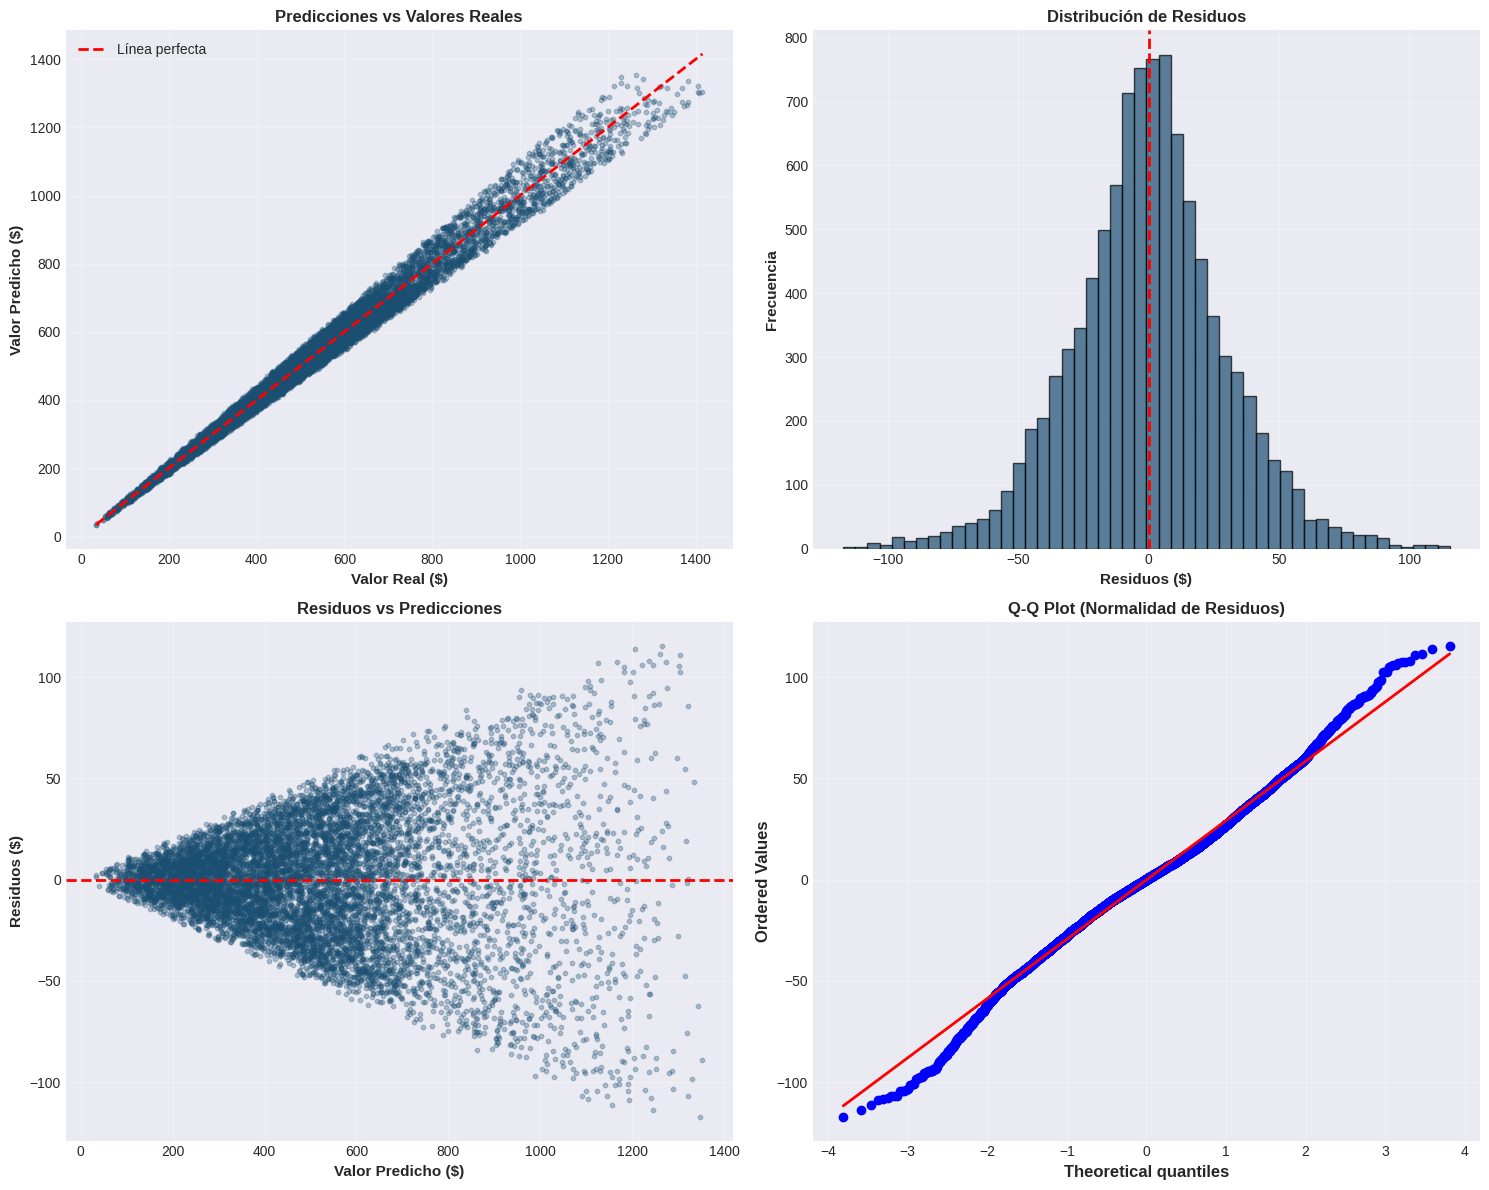


 ESTADÍSTICAS DE RESIDUOS:
   Media: $-0.07 (debe estar cerca de 0)
   Mediana: $0.14
   Desviación estándar: $29.40
   Error absoluto promedio: $22.31


In [ ]:
print("\n" + "="*80)
print(" ANÁLISIS DE RESIDUOS - Linear Regression")
print("="*80)

# Calcular residuos
residuals = y_test - y_test_pred

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicho vs Real
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.3, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Línea perfecta')
axes[0, 0].set_xlabel('Valor Real ($)', fontsize=11)
axes[0, 0].set_ylabel('Valor Predicho ($)', fontsize=11)
axes[0, 0].set_title('Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Distribución de residuos
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuos ($)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Residuos vs Predicciones
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Valor Predicho ($)', fontsize=11)
axes[1, 0].set_ylabel('Residuos ($)', fontsize=11)
axes[1, 0].set_title('Residuos vs Predicciones', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalidad de Residuos)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas
print(f"\n ESTADÍSTICAS DE RESIDUOS:")
print(f"   Media: ${residuals.mean():.2f} (debe estar cerca de 0)")
print(f"   Mediana: ${residuals.median():.2f}")
print(f"   Desviación estándar: ${residuals.std():.2f}")
print(f"   Error absoluto promedio: ${np.abs(residuals).mean():.2f}")



In [ ]:
print(" RESUMEN - PROYECTO FINAL ")
print("-"*100)

print(f"\n OBJETIVO:")
print("   Predecir el costo total de envíos logísticos utilizando Machine Learning")

print(f"\n DATASET:")
print(f"   Registros totales: {len(df):,}")
print(f"   Features utilizadas: {len(all_features)}")
print(f"   División: 80% entrenamiento ({X_train.shape[0]:,}) / 20% prueba ({X_test.shape[0]:,})")

print(f"\n MODELOS EVALUADOS:")
modelos_evaluados = final_results_sorted['Modelo'].tolist()
for i, modelo in enumerate(modelos_evaluados, 1):
    print(f"   {i}. {modelo}")

print(f"\n MEJOR MODELO: {best_model['Modelo']}")
print(f"   R² Score: {best_model['Test_R2']:.4f} ({best_model['Test_R2']*100:.2f}% de varianza explicada)")
print(f"   RMSE: ${best_model['Test_RMSE']:.2f}")
print(f"   MAE: ${best_model['Test_MAE']:.2f}")
print(f"   MAPE: {best_model['Test_MAPE_%']:.2f}%")
print(f"   Overfitting: {best_model['Overfitting']:.4f}")

print(f"\n MEJORA RESPECTO A MODELOS COMPLEJOS:")
baseline_r2 = best_model['Test_R2']
print(f"   Linear Regression (simple) superó a modelos complejos")
print(f"   Esto indica una relación altamente lineal entre features y costo")

print(f"\nTOP 3 FEATURES MÁS IMPORTANTES (según Random Forest Optimizado):")
for i, row in importance_df.head(3).iterrows():
    print(f"   {i+1}. {row['Feature']} (Importancia: {row['Importance']:.4f})")
print("\n\n CONCLUSIONES GENERALES:")
print("   - El modelo de Regresión Lineal obtuvo el mejor desempeño, sugiriendo una relación lineal robusta entre las variables seleccionadas y el costo total.")
print("   - El peso facturable (Chargeable Wt) y los cargos por servicios adicionales (VAS Charges) son los factores más influyentes en la determinación del costo.")
print("   - La transformación logarítmica del Costo Total fue clave para manejar la asimetría de los datos y la presencia de outliers.")
print("   - La creación de variables de interacción (Mode x Weight) y la geolocalización de ciudades aportaron valor significativo al modelo.")
print("\n\n PRÓXIMOS PASOS:")
print("   - Implementación del modelo en un sistema de tarificación en tiempo real.")
print("   - Exploración de técnicas de aprendizaje profundo para capturar patrones más complejos.")
print("   - Monitoreo continuo del desempeño del modelo y reentrenamiento periódico con datos frescos.")
print("   - Incorporación de factores externos como precios del combustible, condiciones climáticas o eventos de demanda.")
print("\n" + "-"*100)

 RESUMEN - PROYECTO FINAL 
----------------------------------------------------------------------------------------------------

 OBJETIVO:
   Predecir el costo total de envíos logísticos utilizando Machine Learning

 DATASET:
   Registros totales: 49,639
   Features utilizadas: 9
   División: 80% entrenamiento (39,711) / 20% prueba (9,928)

 MODELOS EVALUADOS:
   1. Linear Regression
   2. Stacking Regressor
   3. Voting Regressor
   4. Gradient Boosting
   5. XGBoost (Optimizado)
   6. XGBoost
   7. Random Forest (Optimizado)
   8. Random Forest

 MEJOR MODELO: Linear Regression
   R² Score: 0.9860 (98.60% de varianza explicada)
   RMSE: $29.39
   MAE: $22.31
   MAPE: 4.26%
   Overfitting: 0.0004

 MEJORA RESPECTO A MODELOS COMPLEJOS:
   Linear Regression (simple) superó a modelos complejos
   Esto indica una relación altamente lineal entre features y costo

TOP 3 FEATURES MÁS IMPORTANTES (según Random Forest Optimizado):
   1. Chargeable Wt (Importancia: 0.2451)
   2. Volumetric Wt 